# 1. Import Libraries

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

# 2. Initial Settings

In [2]:
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

In [3]:
OUTPUT_DIR = Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TABLE_DIR, FIGURE_DIR

(WindowsPath('outputs/tables'), WindowsPath('outputs/figures'))

In [4]:
def save_table(dataframe, filename):
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False, encoding="utf-8")

In [5]:
def save_current_plot(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3139 entries, 0 to 3138
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3139 non-null   object        
 1   full_title         3139 non-null   object        
 2   document_type      3139 non-null   object        
 3   bureaus            3139 non-null   object        
 4   description        1567 non-null   object        
 5   webpage_url        3139 non-null   object        
 6   selected_txt_urls  3139 non-null   object        
 7   all_txt_urls       3139 non-null   object        
 8   all_txt_count      3139 non-null   int64         
 9   released_on        3139 non-null   datetime64[ns]
 10  issued_on          3139 non-null   datetime64[ns]
 11  adopted            806 non-null    datetime64[ns]
 12  filename           3139 non-null   object        
 13  body_text          3139 non-null   object        
 14  body_wor

In [7]:
# Use released_on as the main document date.
df['date'] = df['released_on'].fillna(df['issued_on'])
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [8]:
# Keep documents from year 2010 to 2025
df = df[df['year'].between(2010, 2025)].reset_index(drop=True)

In [9]:
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    'body_word_count_mean': round(df['body_word_count'].mean()),
    'body_word_count_median': int(df['body_word_count'].median()),
    'min_data': df['date'].min(),
    'max_date': df['date'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

save_table(qc_summary, 'quality_check_summary.csv')

qc_summary

,metric,value
0,number_of_rows,3073
1,number_of_columns,21
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,body_word_count_mean,422
6,body_word_count_median,350
7,min_data,2010-01-05 00:00:00
8,max_date,2025-12-23 00:00:00


In [10]:
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2126
city_prefix_without_date,800
content_after_front_matter,146
letter_salutation,1


In [11]:
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,2959
no_footer_marker,93
commissioner_office_footer,17
trailing_media_contact,2
office_media_footer,1
inline_footer_marker,1


## 3.2. Explore Date Variables

In [12]:
def plot_doc_trend(summary_df, x_label, y_label, filename, tick_every=None):

    cols = summary_df.columns
    period = cols[0]
    var = cols[1]
    num_of_rows = len(summary_df)

    x_pos = range(num_of_rows)

    if tick_every == None:
        tick_every = 1
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])
    
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    tick_positions = list(range(0, num_of_rows, tick_every))
    
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )
    
    plt.tight_layout()

    save_current_plot(filename)
    
    plt.show()

In [13]:
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

save_table(word_stats_by_year, 'word_stats_by_year.csv')

word_stats_by_year

,year,count,mean,median,min,max
0,2010,223,402.511211,344.0,39,2600
1,2011,161,466.180124,376.0,99,2811
2,2012,142,451.978873,387.0,69,1528
3,2013,134,445.276119,393.5,69,4072
4,2014,144,375.020833,343.0,86,1317
5,2015,141,406.319149,366.0,71,2229
6,2016,112,393.383929,370.0,49,899
7,2017,183,349.508197,307.0,48,2242
8,2018,192,374.531250,320.0,25,1452
9,2019,214,404.280374,353.0,126,1992


In [14]:
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

save_table(doc_by_year, 'number_of_documents_by_year.csv')
save_table(doc_by_quarter, 'number_of_documents_by_quarter.csv')
save_table(doc_by_month, 'number_of_documents_by_month.csv')

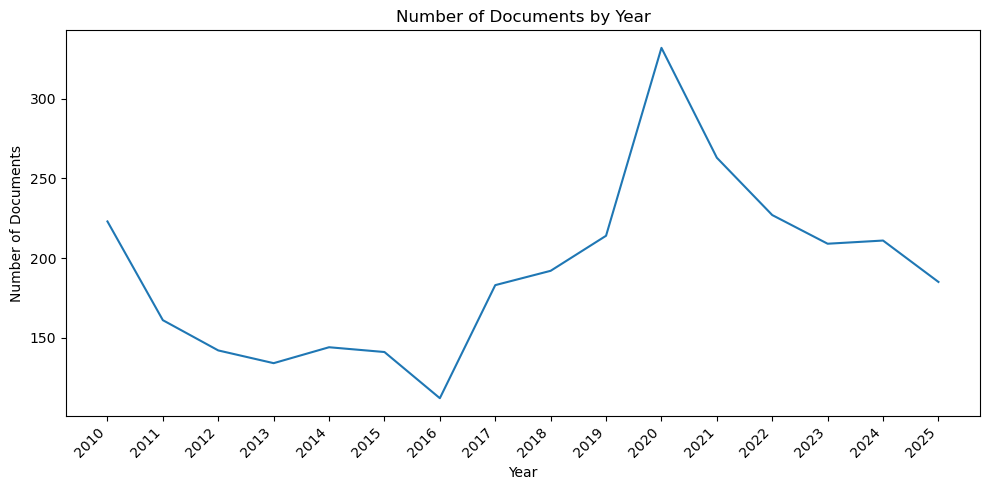

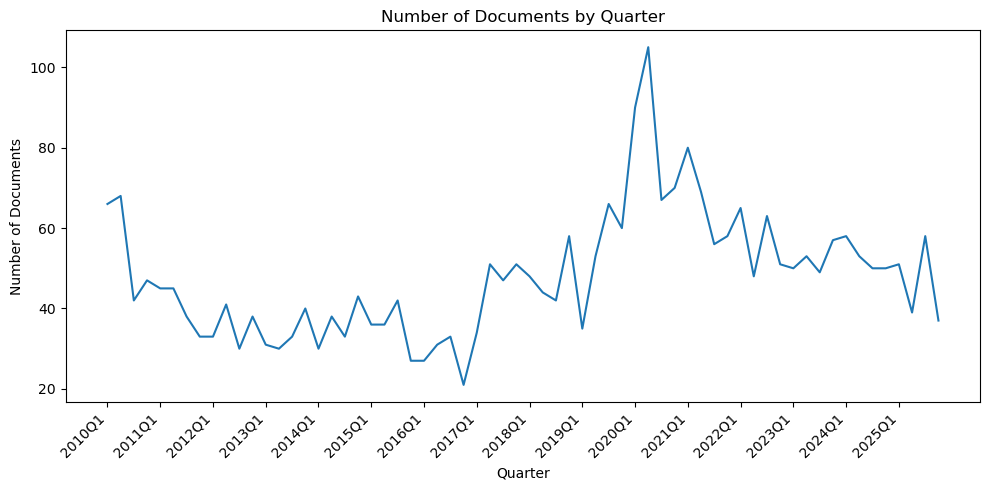

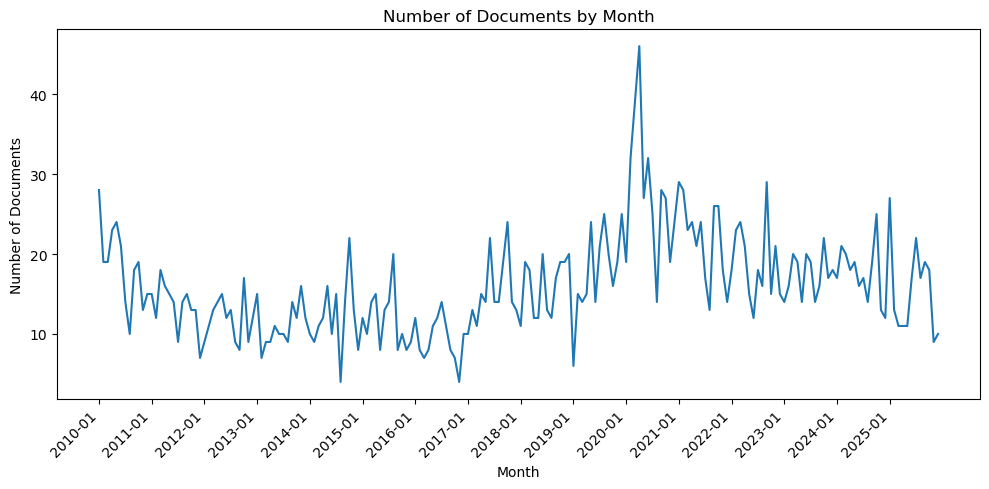

In [15]:
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 'number_of_documents_by_year.png')

plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 'number_of_documents_by_quarter.png', 4)

plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 'number_of_documents_by_month.png', 12)

In [16]:
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('avg_words_per_document').reset_index()

save_table(avg_words_by_year, 'average_number_of_words_by_year.csv')
save_table(avg_words_by_quarter, 'average_number_of_words_by_quarter.csv')
save_table(avg_words_by_month, 'average_number_of_words_by_month.csv')

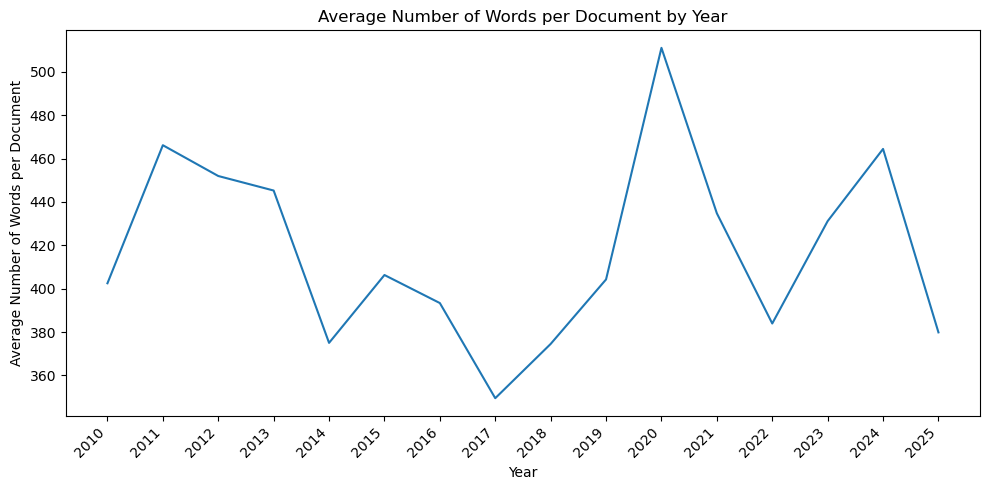

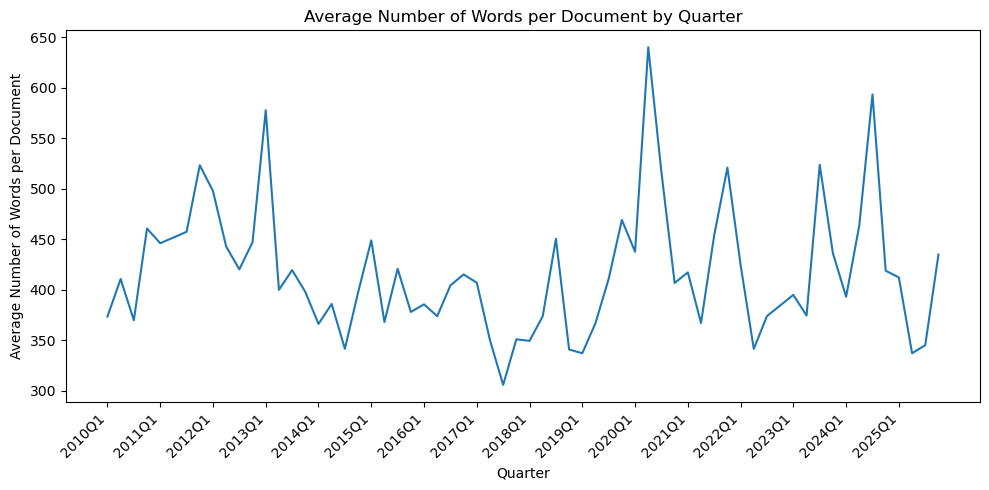

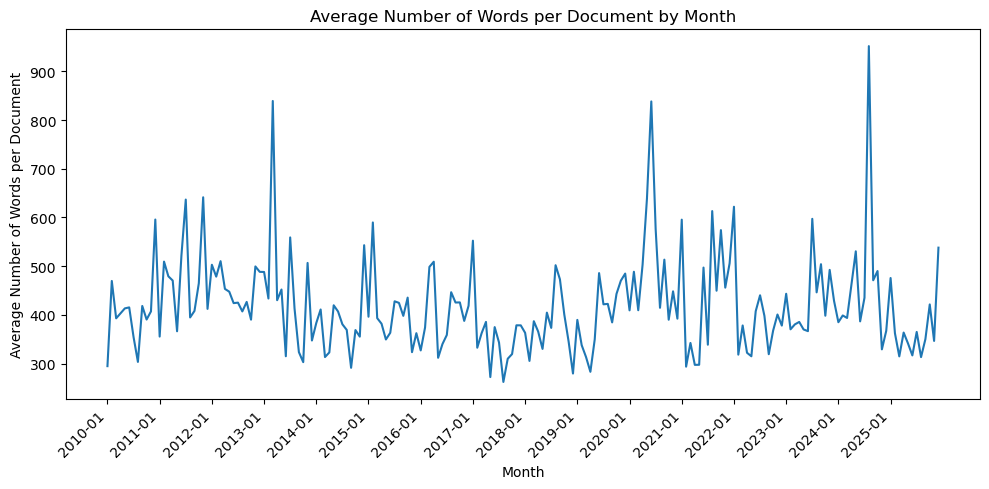

In [17]:
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words per Document', 'average_number_of_words_by_year.png')

plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words per Document', 'average_number_of_words_by_quarter.png', 4)

plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words per Document', 'average_number_of_words_by_month.png', 12)

# 4. Text Preprocessing

## 4.1. Policy Dictionary and Technical-Term


### 4.1.1. Helper Functions

In [18]:
def clean_word(word):
    '''
    Normalize a word
    '''
    word = str(word).lower().strip()
    word = re.sub(r'[^a-z0-9_-]', '', word)
    return word

In [19]:
def normalize_technical_phrases(text):
    '''
    Normalize important telecommunications phrases before spaCy tokenization.
    '''
    if pd.isna(text):
        return ''

    text = str(text)

    for pattern, replacement in technical_phrase_patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    return text

In [20]:
def make_technical_terms(policy_dictionary):
    terms = set(manual_technical_terms)

    for _, replacement in technical_phrase_patterns:
        cleaned_replacement = clean_word(replacement)
        if cleaned_replacement:
            terms.add(cleaned_replacement)

    for dictionary_terms in policy_dictionary.values():
        for term in dictionary_terms:
            normalized_term = normalize_technical_phrases(term)
            for piece in re.findall(r'[A-Za-z0-9_/-]+', normalized_term):
                cleaned_piece = clean_word(piece)
                if not cleaned_piece:
                    continue

                is_technical_like = (
                    cleaned_piece in manual_technical_terms
                    or '_' in cleaned_piece
                    or any(char.isdigit() for char in cleaned_piece)
                    or (piece.isupper() and len(cleaned_piece) <= 8)
                )

                if is_technical_like and cleaned_piece not in STOP_WORDS:
                    terms.add(cleaned_piece)

    return terms

### 4.1.2. Setup Dictionary and Terms

In [21]:
policy_dictionary = {
    'accessibility': [
        'accessibility', 'accessibility clearinghouse', 'accessible emergency information',
        'american sign language', 'asl', 'audible crawl', 'audio description', 'captioning',
        'closed captioning', 'closed captioning display settings',
        'communications and video accessibility act', 'cvaa', 'disabilities', 'disability',
        'disability advisory committee', 'hearing aid compatibility', 'hearing aid compatible',
        'internet protocol captioned telephone service', 'ip cts', 'ip relay',
        'people with disabilities', 'real time text', 'real-time text', 'relay service', 'rtt',
        'telecommunications relay service', 'trs', 'tty', 'video description',
        'video relay service', 'video relay services', 'vrs',
    ],
    'broadband': [
        'bdc', 'bead', 'broadband', 'broadband access', 'broadband data collection',
        'broadband deployment', 'broadband equity access and deployment', 'broadband internet',
        'broadband map', 'broadband mapping', 'broadband maps', 'broadband providers',
        'broadband service', 'broadband services', 'digital discrimination', 'digital divide',
        'digital equity', 'digital inclusion', 'high speed internet', 'internet access',
        'internet service', 'national broadband map', 'national broadband plan', 'rural areas',
        'rural broadband', 'tribal communities', 'tribal lands', 'tribal priority window',
    ],
    'compliance': [
        'apparent liability', 'citation', 'citation and order', 'civil penalty', 'compliance',
        'compliance plan', 'consent decree', 'enforcement', 'enforcement action',
        'field office', 'fine', 'fines', 'forfeiture', 'forfeiture order', 'fraud abuse',
        'investigation', 'investigations', 'nal', 'notice of apparent liability', 'penalty',
        'pirate act', 'pirate radio', 'preventing illegal radio abuse through enforcement act',
        'settlement', 'settlement agreement', 'unauthorized operation', 'violation',
        'violations', 'waste fraud abuse', 'waste fraud and abuse',
    ],
    'competition': [
        'acquisition', 'antitrust', 'broadband competition', 'business data services',
        'common carrier', 'competition', 'competitive', 'competitive bidding',
        'competitiveness', 'deregulation', 'deregulatory initiative', 'forbearance',
        'intercarrier compensation', 'interconnection', 'market power', 'merger',
        'merger review', 'net neutrality', 'north american numbering council',
        'number portability', 'numbering plan', 'numbering resources', 'obsolete rules',
        'open internet', 'open internet rules', 'outdated rules', 'paperwork reduction',
        'pole attachment', 'pole attachments', 'regulatory burdens', 'regulatory reform',
        'repeal', 'special access', 'technology transition', 'technology transitions',
        'toll free numbering', 'video marketplace', 'wireline competition',
    ],
    'media_broadcasting': [
        'am radio', 'am revitalization', 'atsc', 'atsc 3.0', 'broadcast', 'broadcast internet',
        'broadcast ownership', 'broadcast station', 'broadcast stations',
        'broadcast television', 'broadcaster', 'broadcasters', 'broadcasting', 'cable',
        'cable operator', 'cable operators', 'dbs', 'digital television',
        'direct broadcast satellite', 'dtv', 'eeo', 'equal employment opportunity',
        'fm booster', 'fm boosters', 'fm radio', 'fm translator', 'foreign sponsorship',
        'foreign sponsorship identification', 'local journalism', 'low power fm',
        'low power television', 'lpfm', 'lptv', 'media ownership',
        'multichannel video programming distributor', 'mvpd', 'next gen tv', 'nextgen tv',
        'quadrennial review', 'radio', 'radio station', 'retransmission consent', 'television',
        'television station', 'video programming', 'video programming distributor',
    ],
    'national_security': [
        'bgp', 'bgp routing', 'border gateway protocol', 'cable landing',
        'cable landing license', 'china mobile', 'china telecom', 'china unicom',
        'communications equipment', 'comnet', 'covered communications equipment',
        'covered equipment', 'covered list', 'covered list entities', 'cyber',
        'cyber security', 'cyber trust mark', 'cybersecurity',
        'cybersecurity labeling program', 'dahua', 'dji', 'equipment authorization',
        'equipment authorization process', 'equipment authorization program',
        'equipment authorization rules', 'foreign adversaries', 'foreign adversary',
        'foreign ownership', 'foreign ownership review', 'hikvision', 'huawei',
        'international section 214', 'iot labeling', 'iot labeling program', 'kaspersky',
        'national security', 'national security threat', 'network equipment',
        'pacific networks', 'rip and replace', 'section 214', 'section 214 authority',
        'section 214 authorization', 'section 214 authorizations',
        'secure and trusted communications networks', 'secure by design',
        'secure equipment act', 'secure networks act', 'submarine cable',
        'submarine cable landing', 'submarine cables', 'supply chain', 'supply chain risk',
        'supply chain security', 'team telecom', 'test lab', 'u.s. cyber trust mark', 'zte',
    ],
    'public_safety': [
        '911', '911 call', '911 calls', '911 service', '988', '988 lifeline',
        '988 suicide crisis lifeline', 'alerting', 'amber alert', 'amber alerts',
        'communications outage', 'communications outages', 'crisis lifeline', 'dirs',
        'disaster', 'disaster information reporting system', 'disaster response', 'disasters',
        'e911', 'eas', 'emergency alert', 'emergency alert system', 'emergency alerts',
        'emergency communications', 'emergency response', 'first responder',
        'first responders', 'integrated public alert and warning system', 'ipaws',
        'network outage', 'network outage reporting', 'network outage reporting system',
        'network resiliency', 'next generation 911', 'ng911', 'nors', 'outage', 'outages',
        'psap', 'public alert and warning', 'public safety', 'public safety answering point',
        'resilience', 'suicide crisis lifeline', 'suicide prevention lifeline', 'text 911',
        'text to 911', 'wea', 'wireless emergency alerts',
    ],
    'consumer_privacy': [
        'call blocking', 'caller id', 'caller id authentication', 'consumer privacy',
        'consumer protection', 'cpni', 'cramming', 'customer proprietary network information',
        'data breach', 'do not call', 'do not call registry', 'gateway provider',
        'gateway providers', 'illegal robocall', 'illegal robocalls', 'intermediate provider',
        'intermediate providers', 'junk fax', 'junk faxes', 'know your customer', 'kyc',
        'lead generator', 'lead generators', 'one-to-one consent',
        'personally identifiable information', 'pii', 'port-out fraud', 'privacy', 'robocall',
        'robocall mitigation', 'robocall mitigation database', 'robocalls', 'robotext',
        'robotexts', 'scam', 'scammer', 'scammers', 'scams', 'sim swapping', 'slamming',
        'spoofing', 'stir shaken', 'stir shaken caller id', 'stir/shaken', 'tcpa',
        'telephone consumer protection act', 'traced act', 'unwanted call', 'unwanted calls',
        'unwanted robocalls', 'voice service provider', 'voice service providers',
    ],
    'satellite_space': [
        'direct to cell', 'direct to device', 'earth station', 'earth stations',
        'fixed satellite service', 'fss', 'geostationary orbit', 'gso', 'leo',
        'low earth orbit', 'mobile satellite service', 'mss', 'ngso', 'ngso satellite',
        'non geostationary', 'non geostationary orbit', 'orbital debris', 'satellite',
        'satellite broadband', 'satellite communications', 'satellite service',
        'satellite services', 'satellite spectrum sharing', 'satellites', 'scs',
        'space based broadband', 'space bureau', 'space debris', 'space station',
        'space stations', 'supplemental coverage from space',
    ],
    'schools_libraries': [
        'campus', 'classroom', 'connected devices', 'e rate', 'e-rate', 'e-rate program',
        'ecf', 'emergency connectivity fund', 'emergency connectivity program',
        'funding for schools', 'libraries', 'schools', 'schools and libraries', 'student',
        'students', 'wi-fi hotspots', 'wifi hotspots',
    ],
    'spectrum_wireless': [
        '2.5 ghz', '3.45 ghz', '3.5 ghz', '4.9 ghz', '5.9 ghz', '12 ghz', '24 ghz', '5g',
        '5g fast plan', '5g fund', '5g fund for rural america', '6 ghz', '6g', 'auction',
        'aws', 'aws-3', 'c band', 'c-v2x', 'cbrs', 'citizens broadband radio service', 'ghz',
        'incentive auction', 'licensed spectrum', 'lte', 'mhz', 'mid band', 'millimeter wave',
        'mobile broadband', 'mobile service', 'mobile wireless', 'open radio access network',
        'open ran', 'radio access network', 'radio access networks', 'ran', 'shared spectrum',
        'spectrum', 'spectrum access', 'spectrum auction', 'spectrum license',
        'spectrum licenses', 'spectrum policy', 'spectrum sharing', 'tv white spaces', 'u-nii',
        'unlicensed devices', 'unlicensed spectrum', 'unlicensed use', 'v2x', 'wcs',
        'white space', 'white spaces', 'wi-fi', 'wifi', 'wifi 6', 'wireless',
        'wireless broadband', 'wireless communications', 'wireless service',
        'wireless services',
    ],
    'telehealth': [
        'clinic', 'connected care pilot program', 'covid-19 telehealth',
        'covid-19 telehealth program', 'health care', 'health provider', 'hospital', 'medical',
        'patient', 'patients', 'remote monitoring', 'rhc', 'rural health care',
        'rural health care program', 'telehealth', 'telehealth program',
    ],
    'affordability': [
        'a-cam', 'acp', 'affordable connectivity', 'affordable connectivity program',
        'affordable internet', 'broadband label', 'broadband labels',
        'broadband nutrition label', 'caf', 'connect america fund', 'consumer broadband label',
        'consumer broadband labels', 'ebb', 'eligible household',
        'emergency broadband benefit', 'emergency broadband benefit program', 'enhanced a-cam',
        'high cost', 'high cost support', 'household', 'lifeline', 'lifeline program',
        'low income', 'universal service', 'universal service fund', 'usf',
    ]
}

In [22]:
policy_dictionary_summary = pd.DataFrame({
    'policy_category': list(policy_dictionary.keys()),
    'n_terms': [len(terms) for terms in policy_dictionary.values()],
    'list_of_terms': [terms for terms in policy_dictionary.values()]
})

save_table(policy_dictionary_summary, 'policy_dictionary_summary.csv')

policy_dictionary_summary

,policy_category,n_terms,list_of_terms
0,accessibility,32,"[accessibility, accessibility clearinghouse, a..."
1,broadband,28,"[bdc, bead, broadband, broadband access, broad..."
2,compliance,30,"[apparent liability, citation, citation and or..."
3,competition,38,"[acquisition, antitrust, broadband competition..."
4,media_broadcasting,46,"[am radio, am revitalization, atsc, atsc 3.0, ..."
5,national_security,58,"[bgp, bgp routing, border gateway protocol, ca..."
6,public_safety,49,"[911, 911 call, 911 calls, 911 service, 988, 9..."
7,consumer_privacy,52,"[call blocking, caller id, caller id authentic..."
8,satellite_space,31,"[direct to cell, direct to device, earth stati..."
9,schools_libraries,17,"[campus, classroom, connected devices, e rate,..."


In [23]:
technical_phrase_patterns = [
    (r'\bhigh[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+speed\s+internet\b', 'high_speed_internet'),
    (r'\bdigital\s+divide\b', 'digital_divide'),
    (r'\baffordable\s+connectivity\s+program\b', 'acp'),
    (r'\baffordable\s+connectivity\b', 'affordable_connectivity'),
    (r'\bemergency\s+connectivity\s+fund\b', 'ecf'),
    (r'\bemergency\s+connectivity\s+(program|funding)\b', 'emergency_connectivity'),
    (r'\bemergency\s+broadband\s+benefit(\s+program)?\b', 'ebb'),
    (r'\brural\s+digital\s+opportunity\s+fund\b', 'rdof'),
    (r'\bconnect\s+america\s+fund\b', 'caf'),
    (r'\benhanced\s+a[\s\-]*cam\b', 'enhanced_acam'),
    (r'\ba[\s\-]*cam\b', 'acam'),
    (r'\buniversal\s+service\s+fund\b', 'usf'),
    (r'\blifeline\s+program\b', 'lifeline_program'),
    (r'\brural\s+health\s+care(\s+program)?\b', 'rhc'),
    (r'\bcovid[\s\-]*19\s+telehealth\s+program\b', 'covid_telehealth'),
    (r'\btelehealth\s+program\b', 'telehealth_program'),
    (r'\bconnected\s+care\s+pilot\s+program\b', 'connected_care_pilot'),
    (r'\bbroadband\s+equity\s+access\s+and\s+deployment\b', 'bead'),
    (r'\bbroadband\s+data\s+collection\b', 'bdc'),
    (r'\bbroadband\s+deployment\b', 'broadband_deployment'),
    (r'\bbroadband\s+services?\b', 'broadband_service'),
    (r'\bbroadband\s+internet\b', 'broadband_internet'),
    (r'\bbroadband\s+providers?\b', 'broadband_provider'),
    (r'\bnational\s+broadband\s+plan\b', 'national_broadband_plan'),
    (r'\bnational\s+broadband\s+map\b', 'broadband_map'),
    (r'\bbroadband\s+maps?\b', 'broadband_map'),
    (r'\bbroadband\s+mapping\b', 'broadband_map'),
    (r'\b(consumer\s+)?broadband\s+(nutrition\s+)?labels?\b', 'broadband_label'),
    (r'\be[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*rate(\s+program)?\b', 'e_rate'),
    (r'\bhigh[\s\-]*cost\s+(program|support)?\b', 'high_cost'),
    (r'\bdigital\s+equity\b', 'digital_equity'),
    (r'\bdigital\s+inclusion\b', 'digital_inclusion'),
    (r'\bdigital\s+discrimination\b', 'digital_discrimination'),
    (r'\btribal\s+priority\s+window\b', 'tribal_priority_window'),
    (r'\btribal\s+lands?\b', 'tribal_land'),
    (r'\bpole\s+attachments?\b', 'pole_attachment'),
    (r'\b5\s*g\s+fund(\s+for\s+rural\s+america)?\b', '5g_fund'),
    (r'\b5\s*g\b', '5_g'),
    (r'\b6\s*g\b', '6_g'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\s*6\b', 'wifi_6'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\b', 'wifi'),
    (r'\bmid[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'mid_band'),
    (r'\bc[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'c_band'),
    (r'\b2\.5\s*ghz(\s+band)?\b', '2_5_ghz'),
    (r'\b3\.45\s*ghz(\s+band)?\b', '3_45_ghz'),
    (r'\b3\.5\s*ghz(\s+band)?\b', '3_5_ghz'),
    (r'\b4\.9\s*ghz(\s+band)?\b', '4_9_ghz'),
    (r'\b5\.9\s*ghz(\s+band)?\b', '5_9_ghz'),
    (r'\b6\s*ghz(\s+band)?\b', '6_ghz'),
    (r'\b12\s*ghz(\s+band)?\b', '12_ghz'),
    (r'\b24\s*ghz(\s+band)?\b', '24_ghz'),
    (r'\bmillimeter\s+wave\b', 'millimeter_wave'),
    (r'\bmobile\s+broadband\b', 'mobile_broadband'),
    (r'\bwireless\s+broadband\b', 'wireless_broadband'),
    (r'\bwireless\s+communications\b', 'wireless_communications'),
    (r'\bmobile\s+wireless\b', 'mobile_wireless'),
    (r'\bmobile\s+service\b', 'mobile_service'),
    (r'\bcitizens\s+broadband\s+radio\s+service\b', 'cbrs'),
    (r'\btv\s+white\s+spaces?\b', 'tv_white_space'),
    (r'\bwhite\s+spaces?\b', 'white_space'),
    (r'\bopen[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+ran\b', 'open_ran'),
    (r'\bopen\s+radio\s+access\s+networks?\b', 'open_ran'),
    (r'\bradio\s+access\s+networks?\b', 'radio_access_network'),
    (r'\baws[\s\-]*3\b', 'aws_3'),
    (r'\bu[\s\-]*nii\b', 'u_nii'),
    (r'\bc[\s\-]*v2x\b', 'c_v2x'),
    (r'\bcellular\s+vehicle\s+to\s+everything\b', 'c_v2x'),
    (r'\bvehicle\s+to\s+everything\b', 'v2x'),
    (r'\bsatellite\s+services?\b', 'satellite_service'),
    (r'\bsatellite\s+communications\b', 'satellite_communications'),
    (r'\bsatellite\s+broadband\b', 'satellite_broadband'),
    (r'\bspace\s+bureau\b', 'space_bureau'),
    (r'\blow[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+earth\s+orbit\b', 'leo'),
    (r'\bnon[\s\-]*geostationary\s+orbit\b', 'ngso'),
    (r'\bnon[\s\-]*geostationary\b', 'non_geostationary'),
    (r'\bgeostationary\s+orbit\b', 'gso'),
    (r'\bfixed[\s\-]*satellite\s+service\b', 'fss'),
    (r'\bmobile\s+satellite\s+service\b', 'mss'),
    (r'\bearth\s+stations?\b', 'earth_station'),
    (r'\bspace\s+stations?\b', 'space_station'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+device\b', 'direct_to_device'),
    (r'\bdirect\s+to\s+device\b', 'direct_to_device'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+cell\b', 'direct_to_cell'),
    (r'\bdirect\s+to\s+cell\b', 'direct_to_cell'),
    (r'\bsupplemental\s+coverage\s+from\s+space\b', 'scs'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\s+broadband\b', 'space_based_broadband'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\b', 'space_based'),
    (r'\borbital\s+debris\b', 'orbital_debris'),
    (r'\bspace\s+debris\b', 'space_debris'),
    (r'\bstir[\s/\-]+shaken\b', 'stir_shaken'),
    (r'\bshaken[\s/\-]+stir\b', 'stir_shaken'),
    (r'\bdo\s+not\s+call(\s+registry)?\b', 'do_not_call'),
    (r'\bcaller\s+id\b', 'caller_id'),
    (r'\btelephone\s+consumer\s+protection\s+act\b', 'tcpa'),
    (r'\brobocall\s+mitigation\s+database\b', 'robocall_mitigation_database'),
    (r'\brobocall\s+mitigation\b', 'robocall_mitigation'),
    (r'\bvoice\s+service\s+providers?\b', 'voice_service_provider'),
    (r'\bgateway\s+providers?\b', 'gateway_provider'),
    (r'\bintermediate\s+providers?\b', 'intermediate_provider'),
    (r'\bknow[\s\-]*your[\s\-]*customer\b', 'kyc'),
    (r'\bone[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+one\s+consent\b', 'one_to_one_consent'),
    (r'\blead\s+generators?\b', 'lead_generator'),
    (r'\btraced\s+act\b', 'traced_act'),
    (r'\bsim\s+swapping\b', 'sim_swapping'),
    (r'\bport[\s\-]*out\s+fraud\b', 'port_out_fraud'),
    (r'\bcustomer\s+proprietary\s+network\s+information\b', 'cpni'),
    (r'\bpersonally\s+identifiable\s+information\b', 'pii'),
    (r'\bdata\s+breach(?:es)?\b', 'data_breach'),
    (r'\bunwanted\s+calls?\b', 'unwanted_call'),
    (r'\bincarcerated\s+people[^\w]+s\s+communications\s+services\b', 'ipcs'),
    (r'\bincarcerated\s+people\s+communications\s+services\b', 'ipcs'),
    (r'\binmate\s+calling\s+services?\b', 'ics'),
    (r'\bnext\s+generation\s+911\b', 'ng911'),
    (r'\bng\s*[\-]?\s*911\b', 'ng911'),
    (r'\be\s*[\-]?\s*911\b', 'e911'),
    (r'\btext\s+to\s+911\b', 'text_to_911'),
    (r'\bwireless\s+emergency\s+alerts\b', 'wea'),
    (r'\bemergency\s+alert\s+system\b', 'eas'),
    (r'\bpublic\s+safety\s+answering\s+point\b', 'psap'),
    (r'\bdisaster\s+information\s+reporting\s+system\b', 'dirs'),
    (r'\bintegrated\s+public\s+alert\s+and\s+warning\s+system\b', 'ipaws'),
    (r'\bpublic\s+alert\s+and\s+warning\b', 'public_alert_warning'),
    (r'\bnetwork\s+outage\s+reporting\s+system\b', 'nors'),
    (r'\bnetwork\s+outage\s+reporting\b', 'network_outage_reporting'),
    (r'\bnetwork\s+outages?\b', 'network_outage'),
    (r'\bcommunications\s+outages?\b', 'communications_outage'),
    (r'\bemergency\s+communications\b', 'emergency_communications'),
    (r'\bemergency\s+response\b', 'emergency_response'),
    (r'\bdisaster\s+response\b', 'disaster_response'),
    (r'\bfirst\s+responders?\b', 'first_responder'),
    (r'\bamber\s+alerts?\b', 'amber_alert'),
    (r'\b988\s+suicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\b988\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+prevention\s+lifeline\b', 'suicide_prevention_lifeline'),
    (r'\bfm\s+radio\b', 'fm_radio'),
    (r'\bam\s+radio\b', 'am_radio'),
    (r'\bam\s+revitalization\b', 'am_revitalization'),
    (r'\bfm\s+translator\b', 'fm_translator'),
    (r'\bfm\s+boosters?\b', 'fm_booster'),
    (r'\blow\s+power\s+television\b', 'lptv'),
    (r'\blow\s+power\s+tv\b', 'lptv'),
    (r'\blow\s+power\s+fm\b', 'lpfm'),
    (r'\bmultichannel\s+video\s+programming\s+distributor\b', 'mvpd'),
    (r'\bdirect\s+broadcast\s+satellite\b', 'dbs'),
    (r'\bnext[\s\-]*gen\s+tv\b', 'nextgen_tv'),
    (r'\bnextgen\s+tv\b', 'nextgen_tv'),
    (r'\batsc\s*3\.0\b', 'atsc_3_0'),
    (r'\bdigital\s+television\b', 'dtv'),
    (r'\bbroadcast\s+internet\b', 'broadcast_internet'),
    (r'\bquadrennial\s+review\b', 'quadrennial_review'),
    (r'\bforeign\s+sponsorship\s+identification\b', 'foreign_sponsorship'),
    (r'\bequal\s+employment\s+opportunity\b', 'eeo'),
    (r'\bvideo\s+relay\s+services?\b', 'vrs'),
    (r'\btelecommunications\s+relay\s+service\b', 'trs'),
    (r'\binternet\s+protocol\s+captioned\s+telephone\s+service\b', 'ip_cts'),
    (r'\bip[\s\-]+cts\b', 'ip_cts'),
    (r'\bip\s+relay\b', 'ip_relay'),
    (r'\bhearing\s+aid\s+compatibility\b', 'hearing_aid_compatibility'),
    (r'\bhearing\s+aid\s+compatible\b', 'hearing_aid_compatible'),
    (r'\bclosed\s+captioning\s+display\s+settings\b', 'closed_captioning_display'),
    (r'\bclosed\s+captioning\b', 'closed_captioning'),
    (r'\baudio\s+description\b', 'audio_description'),
    (r'\bvideo\s+description\b', 'video_description'),
    (r'\baudible\s+crawl\b', 'audible_crawl'),
    (r'\baccessible\s+emergency\s+information\b', 'accessible_emergency_information'),
    (r'\bcommunications\s+and\s+video\s+accessibility\s+act\b', 'cvaa'),
    (r'\bamerican\s+sign\s+language\b', 'asl'),
    (r'\breal[\s\-]*time\s+text\b', 'rtt'),
    (r'\brip\s+and\s+replace\b', 'rip_and_replace'),
    (r'\bsecure\s+and\s+trusted\s+communications\s+networks\b', 'secure_trusted_networks'),
    (r'\bsecure\s+networks\s+act\b', 'secure_networks_act'),
    (r'\bsecure\s+equipment\s+act\b', 'secure_equipment_act'),
    (r'\bcyber\s+security\b', 'cybersecurity'),
    (r'\bcovered\s+communications\s+equipment\b', 'covered_communications_equipment'),
    (r'\bcommunications\s+equipment\b', 'communications_equipment'),
    (r'\bcovered\s+equipment\b', 'covered_equipment'),
    (r'\bcovered\s+list\s+entities\b', 'covered_list'),
    (r'\bcovered\s+list\b', 'covered_list'),
    (r'\bequipment\s+authorization\s+program\b', 'equipment_authorization_program'),
    (r'\bequipment\s+authorization\s+(process|rules)\b', 'equipment_authorization'),
    (r'\bchina\s+telecom\b', 'china_telecom'),
    (r'\bchina\s+mobile\b', 'china_mobile'),
    (r'\bchina\s+unicom\b', 'china_unicom'),
    (r'\bpacific\s+networks\b', 'pacific_networks'),
    (r'\binternational\s+section\s+214\b', 'international_section_214'),
    (r'\bsection\s+214\b', 'section_214'),
    (r'\bteam\s+telecom\b', 'team_telecom'),
    (r'\bforeign\s+ownership\s+review\b', 'foreign_ownership_review'),
    (r'\bforeign\s+ownership\b', 'foreign_ownership'),
    (r'\bsubmarine\s+cable\s+landing\s+licenses?\b', 'submarine_cable_landing_license'),
    (r'\bsubmarine\s+cable\s+landing\b', 'submarine_cable_landing'),
    (r'\bsubmarine\s+cables?\b', 'submarine_cable'),
    (r'\bcable\s+landing\s+licenses?\b', 'cable_landing_license'),
    (r'\bcable\s+landing\b', 'cable_landing'),
    (r'\bcyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\bu\.?s\.?\s+cyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\binternet\s+of\s+things\b', 'iot'),
    (r'\biot\s+(cybersecurity\s+)?labeling(\s+program)?\b', 'iot_labeling'),
    (r'\bcybersecurity\s+labeling\s+program\b', 'iot_labeling'),
    (r'\bartificial\s+intelligence\b', 'ai'),
    (r'\bai[\s\-]*generated\b', 'ai_generated'),
    (r'\bunmanned\s+aircraft\s+systems\b', 'uas'),
    (r'\bborder\s+gateway\s+protocol\b', 'bgp'),
    (r'\bbgp\s+routing\b', 'bgp_routing'),
    (r'\bnotice\s+of\s+apparent\s+liability\b', 'nal'),
    (r'\benforcement\s+action\b', 'enforcement_action'),
    (r'\bfield\s+office\b', 'field_office'),
    (r'\bnotice\s+of\s+violation\b', 'notice_of_violation'),
    (r'\bcitation\s+and\s+order\b', 'citation_order'),
    (r'\bconsent\s+decree\b', 'consent_decree'),
    (r'\bpirate\s+radio\b', 'pirate_radio'),
    (r'\bpirate\s+act\b', 'pirate_act'),
    (r'\bwaste\s+fraud\s+and\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bwaste\s+fraud\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bopen\s+internet\b', 'open_internet'),
    (r'\bnet\s+neutrality\b', 'net_neutrality'),
    (r'\bmerger\s+review\b', 'merger_review'),
    (r'\bbusiness\s+data\s+services\b', 'business_data_services'),
    (r'\bintercarrier\s+compensation\b', 'intercarrier_compensation'),
    (r'\btechnology\s+transitions?\b', 'technology_transition'),
    (r'\bnumber\s+portability\b', 'number_portability'),
    (r'\bnorth\s+american\s+numbering\s+council\b', 'nanc'),
    (r'\bnumbering\s+resources\b', 'numbering_resources'),
    (r'\btoll\s+free\s+numbering\b', 'toll_free_numbering'),
    (r'\bderegulatory\s+initiative\b', 'deregulatory_initiative'),
    (r'\boutdated\s+rules\b', 'outdated_rules'),
    (r'\bobsolete\s+rules\b', 'obsolete_rules'),
    (r'\bcall\s+blocking\b', 'call_blocking')
]

In [24]:
# Technical tokens to preserve before stopword, number, and POS filtering.
manual_technical_terms = {
    '2_5_ghz', '3_45_ghz', '3_5_ghz', '4_9_ghz', '5_9_ghz',
    '5_g', '5g', '5g_fund', '6_ghz', '6_g', '6g', '12_ghz', '24_ghz',
    '911', '988', '988_lifeline', 'acp', 'acam', 'accessibility',
    'affordable_connectivity', 'ai', 'ai_generated', 'am_radio',
    'am_revitalization', 'amber_alert', 'asl', 'atsc',
    'atsc_3_0', 'auction', 'audible_crawl', 'aws', 'aws_3', 'bdc', 'bead',
    'bgp', 'bgp_routing', 'broadcast', 'broadcaster', 'broadcasting',
    'broadband', 'broadband_deployment', 'broadband_internet',
    'broadband_label', 'broadband_map', 'broadband_provider',
    'broadband_service', 'burdensome', 'business_data_services', 'c_band', 'c_v2x', 'cable', 'cable_landing',
    'cable_landing_license', 'caf', 'caller_id', 'captioning', 'cbrs', 'closed_captioning',
    'closed_captioning_display', 'communications_equipment',
    'communications_outage', 'competition', 'connected_care_pilot',
    'consent_decree', 'covered_communications_equipment', 'covered_equipment',
    'covered_list', 'covid_telehealth', 'cpni', 'cvaa', 'cyber',
    'cyber_trust_mark', 'cybersecurity', 'data_breach', 'dahua', 'dbs',
    'digital_discrimination', 'digital_divide', 'digital_equity',
    'deregulatory_initiative', 'digital_inclusion', 'direct_to_cell', 'direct_to_device', 'dirs',
    'disability', 'dji', 'do_not_call', 'dtv', 'e_rate', 'e911', 'eas', 'ebb', 'ecf', 'eeo',
    'emergency_communications', 'emergency_connectivity', 'emergency_response',
    'enforcement', 'enforcement_action', 'enhanced_acam',
    'equipment_authorization', 'equipment_authorization_program', 'field_office',
    'first_responder', 'fm_booster', 'fm_radio', 'fm_translator', 'foreign_ownership',
    'foreign_ownership_review', 'foreign_sponsorship', 'forfeiture', 'fraud',
    'fss', 'gso', 'ghz', 'hearing_aid_compatibility', 'hearing_aid_compatible',
    'high_cost', 'high_speed_internet', 'hikvision', 'huawei', 'ics', 'iot',
    'iot_labeling', 'ip_cts', 'ip_relay', 'ipaws', 'ipcs', 'kaspersky', 'kyc',
    'lead_generator', 'leo', 'lifeline', 'lifeline_program', 'lpfm', 'lptv',
    'lte', 'merger_review', 'mhz', 'mid_band', 'millimeter_wave', 'mobile_broadband',
    'mobile_service', 'mobile_wireless', 'mss', 'mvpd',
    'nal', 'nanc', 'net_neutrality', 'network_outage', 'network_outage_reporting',
    'ng911', 'ngso', 'non_geostationary', 'nors', 'notice_of_violation',
    'number_portability', 'numbering_resources', 'one_to_one_consent',
    'obsolete_rules', 'open_internet', 'open_ran', 'orbit', 'orbital_debris',
    'outdated_rules', 'pacific_networks',
    'penalty', 'pii', 'pirate_act', 'pirate_radio', 'pole_attachment', 'port_out_fraud', 'psap',
    'public_alert_warning', 'quadrennial_review', 'radio', 'radio_access_network',
    'ran', 'rdof', 'rhc', 'rip_and_replace', 'robocall', 'robocall_mitigation',
    'robocall_mitigation_database', 'robotext', 'rtt', 'scs', 'section_214',
    'secure_equipment_act', 'secure_networks_act', 'secure_trusted_networks',
    'sim_swapping', 'satellite', 'satellite_broadband', 'satellite_communications',
    'satellite_service', 'scam', 'space', 'space_based', 'space_based_broadband',
    'space_bureau', 'space_debris', 'space_station', 'spectrum', 'spoofing',
    'stir_shaken', 'submarine_cable', 'submarine_cable_landing',
    'submarine_cable_landing_license', 'suicide_prevention_lifeline',
    'tcpa', 'team_telecom', 'telehealth', 'telehealth_program', 'television',
    'text_to_911', 'toll_free_numbering', 'traced_act', 'tribal_land',
    'tribal_priority_window', 'trs', 'tty', 'tv_white_space', 'uas', 'u_nii',
    'uhf', 'unwanted_call', 'usac', 'usf', 'v2x', 'vhf', 'violation',
    'voice_service_provider', 'vrs', 'waste_fraud_abuse', 'wcs', 'wea',
    'white_space', 'wifi', 'wifi_6', 'wireless', 'wireless_broadband',
    'wireless_communications', 'zte'
}

In [25]:
allowed_pos = {'NOUN', 'ADJ', 'VERB'}

domain_stopwords = {
    'fcc', 'federal', 'communication', 'commission',
    'commissioner', 'chairman', 'chairwoman', 'today',
    'announce', 'release', 'statement', 'order', 'rule',
    'rulemaking', 'notice', 'propose', 'proposal', 'adopt',
    'action', 'docket', 'document', 'information', 'background',
    'additional', 'separate', 'approve', 'issue', 'bureau',
    'office', 'media', 'contact', 'washington', 'dc', 'us', 'united', 'state',
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'am', 'pm'
}

In [26]:
technical_terms = make_technical_terms(policy_dictionary)

technical_terms_df = pd.DataFrame({
    'technical_term': sorted(technical_terms)
})

save_table(technical_terms_df, 'technical_termns.csv')

technical_terms_df

,technical_term
0,12_ghz
1,24_ghz
2,2_5_ghz
3,3_45_ghz
4,3_5_ghz
...,...
258,wifi_6
259,wireless
260,wireless_broadband
261,wireless_communications


## 4.2. Preprocessing the Body Text

In [27]:
# Load the English spaCy model.
# 1) Keep the tagger and lemmatizer for POS filtering and lemmatization.
# 2) Disable parser and NER: they are not needed for basic preprocessing.

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

text_lengths = df['body_text'].astype(str).str.len()
nlp.max_length = max(nlp.max_length, 3000000)

nlp.pipe_names

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']

In [28]:
def preprocess_doc(doc):
    '''
    Convert one spaCy Doc object into a list of cleaned lemma tokens.

    Technical tokens are preserved before stopword, number, and POS filtering.
    Ordinary words are lemmatized normally.
    '''
    tokens = []

    for token in doc:

        # formatting and punctuation tokens
        if token.is_space or token.is_punct or token.is_quote or token.is_bracket:
            continue
        # remove URLs and emails first
        if token.like_url or token.like_email:
            continue

        token_text = clean_word(token.text)

        # preserve important technical tokens 
        if token_text in technical_terms:
            tokens.append(token_text)
            continue

        # remove common or non-topic tokens
        if token.is_stop or token.like_num:
            continue
        # keep only selected parts of speech (pos)
        if token.pos_ not in allowed_pos:
            continue

        lemma = clean_word(token.lemma_)

        if len(lemma) < 2:
            continue
        if lemma in domain_stopwords:
            continue

        tokens.append(lemma)

    return tokens

In [29]:
df['normalized_body_text'] = df['body_text'].map(normalize_technical_phrases)

texts = df['normalized_body_text'].tolist()

tokens = []

for doc in tqdm(nlp.pipe(texts, batch_size=32), total=len(texts)):
    tokens.append(preprocess_doc(doc))

df['tokens'] = tokens
df['clean_text'] = df['tokens'].map(lambda tokens: ' '.join(tokens))
df['token_count'] = df['tokens'].map(len)

  0%|          | 0/3073 [00:00<?, ?it/s]

In [30]:
df[['filename', 'page_title', 
    'date', 'year', 'quarter', 
    'body_word_count', 'body_text', 
    'token_count', 'clean_text']]

,filename,page_title,date,year,quarter,body_word_count,body_text,token_count,clean_text
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,Chairman Carr Highlights Wins Delivered in 2025,2025-12-23,2025,2025Q4,2257,"Today, Chairman Carr summarized some of the FC...",1058,summarize key win historic year proud win able...
1,251222_Gomez_on_Editorial_Interference_at_60_M...,Gomez on Editorial Interference at 60 Minutes,2025-12-22,2025,2025Q4,271,FCC Commissioner Anna M. Gomez issued the foll...,127,follow response report delay segment follow go...
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,FCC Updates Covered List to Add Certain UAS an...,2025-12-22,2025,2025Q4,690,As President Trump stated in the Restoring Ame...,292,uas uas know drone offer potential enhance pub...
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,FCC Combats Robocallers' Abuse of Phone Number...,2025-12-18,2025,2025Q4,405,The Federal Communications Commission today ad...,173,change prevent phone numbering_resources abuse...
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,FCC Deletes Outdated Rules on Long-Forgotten T...,2025-12-18,2025,2025Q4,217,"In its latest installment of the Delete, Delet...",78,late installment proceeding vote eliminate reg...
...,...,...,...,...,...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...","Statement of William T. Lake, Chief, Media Bur...",2010-01-07,2010,2010Q1,82,Today Sinclair and Mediacom have completed the...,34,complete retransmission consent negotiation re...
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,FCC Launches Reboot.FCC.gov to Engage Public i...,2010-01-07,2010,2010Q1,327,"Today, the Federal Communications Commission l...",147,launch web site dedicate solicit public input ...
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,PANELISTS ANNOUNCED FOR JANUARY 13 WORKSHOP ON...,2010-01-06,2010,2010Q1,288,The Federal Communications Commission will hol...,82,hold staff workshop innovation investment open...
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,MEDIA BUREAU ANNOUNCES PANELISTS AND AGENDA FO...,2010-01-05,2010,2010Q1,269,The Media Bureau today announced the panelists...,73,panelist agenda medium ownership workshop hold...


In [31]:
token_count_series = df['token_count']

preprocessing_summary_dict = {
    'number_of_documents': int(df.shape[0]),
    'min_token_count': int(token_count_series.min()),
    'mean_token_count': int(round(token_count_series.mean())),
    'median_token_count': int(token_count_series.median()),
    'max_token_count': int(token_count_series.max())
}

preprocessing_summary = pd.DataFrame(
    preprocessing_summary_dict.items(),
    columns=['metric', 'value']
)

save_table(preprocessing_summary, 'preprocessing_summary.csv')

preprocessing_summary

,metric,value
0,number_of_documents,3073
1,min_token_count,6
2,mean_token_count,166
3,median_token_count,136
4,max_token_count,3616


# 5. Term Frequency

## 5.1. Raw Term Frequency

### 5.1.1. Overall

In [32]:
count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_counts = count_vectorizer.fit_transform(df['clean_text'].fillna(''))

terms = count_vectorizer.get_feature_names_out()

In [33]:
term_counts = np.asarray(X_counts.sum(axis=0)).ravel()

term_freq = pd.DataFrame({
    'term': terms,
    'count': term_counts.astype(int)
})

term_freq = term_freq.sort_values('count', ascending=False).reset_index(drop=True)

save_table(term_freq, 'raw_term_frequency.csv')

term_freq.head(20)

,term,count
0,service,6718
1,consumer,4203
2,provide,3864
3,include,3619
4,broadband,3465
5,provider,3284
6,public,3074
7,support,2926
8,access,2809
9,new,2800


### 5.1.2. Trends by Year, Quarter and Month

In [34]:
def get_term_frequency_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        counts = np.asarray(X[idx].sum(axis=0)).ravel()
        top_idx = counts.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'count': counts[top_idx].astype(int)
        })

        period_result = period_result[period_result['count'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [35]:
term_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='year',
    top_n=5
)

term_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='quarter',
    top_n=5
)

term_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='month',
    top_n=5
)

In [36]:
save_table(term_freq_by_year, 'raw_term_frequency_by_year.csv')
save_table(term_freq_by_quarter, 'raw_term_frequency_by_quarter.csv')
save_table(term_freq_by_month, 'raw_term_frequency_by_month.csv')

In [37]:
term_freq_by_year.head(20)

,year,term,count
0,2010,service,458
1,2010,broadband,422
2,2010,public,378
3,2010,include,325
4,2010,consumer,312
5,2011,service,356
6,2011,broadband,330
7,2011,consumer,253
8,2011,public,224
9,2011,provide,202


In [38]:
term_freq_by_quarter.head(20)

,quarter,term,count
0,2010Q1,broadband,157
1,2010Q1,service,113
2,2010Q1,public,101
3,2010Q1,include,94
4,2010Q1,consumer,73
5,2010Q2,public,156
6,2010Q2,broadband,148
7,2010Q2,service,145
8,2010Q2,consumer,100
9,2010Q2,network,100


In [39]:
term_freq_by_month.head(20)

,month,term,count
0,2010-01,consumer,45
1,2010-01,public,41
2,2010-01,radio,31
3,2010-01,include,30
4,2010-01,service,25
5,2010-02,broadband,63
6,2010-02,service,45
7,2010-02,network,39
8,2010-02,speed,36
9,2010-02,include,35


## 5.2. N-Gram Frequency

### 5.2.1. Overall

In [40]:
def get_ngram_frequency(df, text_col, ngram_range, max_df=1.0, min_df=1):
    ngram_vectorizer = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_ngrams = ngram_vectorizer.fit_transform(df[text_col].fillna(''))

    ngram_terms = ngram_vectorizer.get_feature_names_out()

    ngram_counts = np.asarray(X_ngrams.sum(axis=0)).ravel()

    ngram_freq = pd.DataFrame({
        'ngram': ngram_terms,
        'count': ngram_counts.astype(int)
    })

    ngram_freq = (
        ngram_freq
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    return ngram_freq, X_ngrams, ngram_terms

In [41]:
bigram_freq, X_bigrams, bigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

save_table(bigram_freq, 'bigram_frequency.csv')

bigram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


In [42]:
trigram_freq, X_trigrams, trigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

save_table(trigram_freq, 'trigram_frequency.csv')

trigram_freq.head(20)

,ngram,count
0,health care provider,274
1,remote patient monitoring,184
2,item agenda schedule,125
3,waste fraud abuse,114
4,low income patient,113
5,award laptop computer,109
6,page cover sheet,102
7,item expect consider,102
8,draft text item,101
9,draft help summarize,101


In [43]:
ngram_freq, X_ngrams, ngram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

save_table(ngram_freq, 'ngram_frequency.csv')

ngram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


### 5.2.2. Trends by Year, Quarter and Month

In [44]:
ngram_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='year',
    top_n=5
)

ngram_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='quarter',
    top_n=5
)

ngram_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='month',
    top_n=5
)

In [45]:
save_table(ngram_freq_by_year, 'ngram_frequency_by_year.csv')
save_table(ngram_freq_by_quarter, 'ngram_frequency_by_quarter.csv')
save_table(ngram_freq_by_month, 'ngram_frequency_by_month.csv')

ngram_freq_by_year.head(20)

,year,term,count
0,2010,public safety,117
1,2010,people disability,56
2,2010,seek comment,51
3,2010,health care,45
4,2010,broadband network,38
5,2011,public safety,53
6,2011,small business,52
7,2011,seek comment,44
8,2011,low income,40
9,2011,service provider,28


## 5.3. TF-IDF Scores

### 5.3.1. Overall (1): Raw Term

In [46]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

In [47]:
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

tfidf_scores = pd.DataFrame({
    'term': tfidf_terms,
    'tfidf_mean': tfidf_mean,
    'document_frequency': document_frequency
})

tfidf_scores = (
    tfidf_scores
    .sort_values('tfidf_mean', ascending=False)
    .reset_index(drop=True)
)

save_table(tfidf_scores, 'tfidf_scores.csv')

tfidf_scores.head(20)

,term,tfidf_mean,document_frequency
0,service,0.038729,1881
1,consumer,0.033075,1233
2,broadband,0.031475,968
3,spectrum,0.028344,619
4,public,0.025876,1398
5,wireless,0.025233,992
6,support,0.024988,1101
7,work,0.024514,1198
8,provider,0.024108,1090
9,provide,0.023510,1695


### 5.3.2. Overall (2): N-Gram

In [48]:
def get_tfidf_scores(df, text_col, ngram_range, max_df=1.0, min_df=1):
    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_tfidf = tfidf_vectorizer.fit_transform(df[text_col].fillna(''))

    tfidf_terms = tfidf_vectorizer.get_feature_names_out()

    tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
    document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

    tfidf_scores = pd.DataFrame({
        'term': tfidf_terms,
        'tfidf_mean': tfidf_mean,
        'document_frequency': document_frequency
    })

    tfidf_scores = (
        tfidf_scores
        .sort_values('tfidf_mean', ascending=False)
        .reset_index(drop=True)
    )

    return tfidf_scores, X_tfidf, tfidf_terms

In [49]:
tfidf_bigram_scores, X_tfidf_bigram, tfidf_bigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_bigram_scores, 'tfidf_bigram_scores.csv')

tfidf_bigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.014030,524
1,public safety,0.013417,381
2,school library,0.010826,154
3,service provider,0.009257,353
4,national security,0.008919,178
5,health care,0.008523,193
6,low income,0.007614,207
7,protect consumer,0.006199,213
8,public interest,0.006130,163
9,rural area,0.006067,240


In [50]:
tfidf_trigram_scores, X_tfidf_trigram, tfidf_trigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_trigram_scores, 'tfidf_trigram_scores.csv')

tfidf_trigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,health care provider,0.007917,89
1,waste fraud abuse,0.006841,86
2,serve public interest,0.006153,42
3,high speed broadband,0.005502,71
4,item agenda schedule,0.005315,125
5,low income consumer,0.005245,64
6,seek public comment,0.005098,51
7,internet service provider,0.004978,53
8,open meeting schedule,0.004793,62
9,agenda open meeting,0.004793,62


In [51]:
tfidf_ngram_scores, X_tfidf_ngram, tfidf_ngram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_ngram_scores, 'tfidf_ngram_scores.csv')

tfidf_ngram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.012708,524
1,public safety,0.012255,381
2,school library,0.009129,154
3,service provider,0.008497,353
4,national security,0.008000,178
5,health care,0.007725,193
6,low income,0.006865,207
7,public interest,0.005705,163
8,protect consumer,0.005549,213
9,rural area,0.005538,240


### 5.3.3. Trends by Year, Quarter and Month

In [52]:
def get_tfidf_mean_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        tfidf_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        document_frequency = np.asarray((X[idx] > 0).sum(axis=0)).ravel()

        top_idx = tfidf_mean.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'tfidf_mean': tfidf_mean[top_idx],
            'document_frequency': document_frequency[top_idx]
        })

        period_result = period_result[period_result['tfidf_mean'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [53]:
tfidf_by_year = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='year',
    top_n=5
)

tfidf_by_quarter = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='quarter',
    top_n=5
)

tfidf_by_month = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='month',
    top_n=5
)

In [54]:
save_table(tfidf_by_year, 'tfidf_ngram_scores_by_year.csv')
save_table(tfidf_by_quarter, 'tfidf_ngram_scores_by_quarter.csv')
save_table(tfidf_by_month, 'tfidf_ngram_scores_by_month.csv')

In [55]:
tfidf_by_year.head(20)

,year,term,tfidf_mean,document_frequency
0,2010,public safety,0.022704,30
1,2010,people disability,0.020177,37
2,2010,request include,0.013103,27
3,2010,voice tty,0.012643,31
4,2010,mail voice tty,0.012063,27
5,2011,public safety,0.019183,31
6,2011,small business,0.016062,10
7,2011,public interest,0.014590,17
8,2011,seek comment,0.011561,25
9,2011,broadband adoption,0.011071,11


In [56]:
tfidf_by_quarter.head(20)

,quarter,term,tfidf_mean,document_frequency
0,2010Q1,people disability,0.022696,15
1,2010Q1,request include,0.022491,13
2,2010Q1,available request,0.018833,14
3,2010Q1,available request include,0.018602,13
4,2010Q1,request include description,0.018602,13
5,2010Q2,public safety,0.044662,14
6,2010Q2,people disability,0.020783,13
7,2010Q2,universal service,0.017312,7
8,2010Q2,bill shock,0.016614,3
9,2010Q2,send mail voice,0.015425,10


In [57]:
tfidf_by_month.head(20)

,month,term,tfidf_mean,document_frequency
0,2010-01,relief effort,0.037194,3
1,2010-01,look review,0.035184,3
2,2010-01,request include,0.029942,7
3,2010-01,available request,0.025726,8
4,2010-01,send mail voice,0.024415,7
5,2010-02,non adopter,0.042898,1
6,2010-02,telephone number,0.039896,1
7,2010-02,public forum,0.037408,1
8,2010-02,broadband adoption,0.034853,3
9,2010-02,work recommendation,0.031963,3


# 6. Dictionary-Based Policy Focus Analysis

## 6.1. Define Helper Functions

In [58]:
def document_to_tokens(text):
    '''
    Convert a term into the same cleaned-token format
    '''
    normalized_text = normalize_technical_phrases(text)
    doc = nlp(normalized_text)
    
    return preprocess_doc(doc)

In [59]:
def prepare_tokenized_policy_dictionary(policy_dictionary):
    '''
    Convert policy dictionary terms into token sequences.
    '''
    tokenized_dictionary = {}
    skipped_terms = []

    for category, terms in policy_dictionary.items():
        token_sequences = []

        for term in terms:
            
            term_tokens = tuple(document_to_tokens(term))
            original_piece_count = len(re.findall(r'[A-Za-z0-9]+', str(term)))
            normalized_term = normalize_technical_phrases(term)

            if len(term_tokens) == 0:
                skipped_terms.append({
                    'policy_category': category,
                    'term': term,
                    'normalized_term': normalized_term,
                    'tokenized_term': '',
                    'reason': 'empty_after_preprocessing',
                })
                continue
                
            became_single_token = original_piece_count > 1 and len(term_tokens) == 1
            
            single_token_is_technical = (
                len(term_tokens) == 1
                and (
                    term_tokens[0] in technical_terms
                    or '_' in term_tokens[0]
                    or any(char.isdigit() for char in term_tokens[0])
                )
            )

            if became_single_token and not single_token_is_technical:
                skipped_terms.append({
                    'policy_category': category,
                    'term': term,
                    'normalized_term': normalized_term,
                    'tokenized_term': ' '.join(term_tokens),
                    'reason': 'multi_word_term_became_single_generic_token',
                })
                continue

            token_sequences.append(term_tokens)

        tokenized_dictionary[category] = sorted(
            set(token_sequences),
            key=lambda tokens: (len(tokens), sum(len(token) for token in tokens)),
            reverse=True,
        )

    skipped_terms_df = pd.DataFrame(skipped_terms)
    
    return tokenized_dictionary, skipped_terms_df

In [60]:
def count_policy_token_matches(tokens, dictionary_token_sequences):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return 0, ''

    dictionary_token_sequences = [
        tuple(term_tokens)
        for term_tokens in dictionary_token_sequences
        if 0 < len(term_tokens) <= len(tokens)
    ]

    if len(dictionary_token_sequences) == 0:
        return 0, ''

    sequence_lengths = sorted({len(term_tokens) for term_tokens in dictionary_token_sequences}, reverse=True)
    positions_by_sequence = {}

    for term_length in sequence_lengths:
        for start in range(0, len(tokens) - term_length + 1):
            sequence = tuple(tokens[start:start + term_length])
            positions_by_sequence.setdefault(sequence, []).append(start)

    occupied = np.zeros(len(tokens), dtype=bool)
    term_counts = Counter()

    for term_tokens in dictionary_token_sequences:
        term_length = len(term_tokens)
        for start in positions_by_sequence.get(term_tokens, []):
            end = start + term_length
            if occupied[start:end].any():
                continue
            occupied[start:end] = True
            term_counts[' '.join(term_tokens)] += 1

    total_count = int(sum(term_counts.values()))
    matched_terms = '; '.join([
        f'{term} ({count})' if count > 1 else term
        for term, count in term_counts.most_common()
    ])

    return total_count, matched_terms

## 6.2. Count Dictionary Matches

In [61]:
tokenized_policy_dictionary, skipped_policy_terms = prepare_tokenized_policy_dictionary(policy_dictionary)

print(f'Number of skipped policy terms: {len(skipped_policy_terms)}')

tokenized_policy_dictionary_summary = pd.DataFrame([
    {
        'policy_category': category,
        'n_original_terms': len(policy_dictionary[category]),
        'n_tokenized_terms': len(token_sequences),
        'tokenized_dictionary_terms': '; '.join([' '.join(tokens) for tokens in token_sequences])
    }
    for category, token_sequences in tokenized_policy_dictionary.items()
])

save_table(tokenized_policy_dictionary_summary, 'tokenized_policy_dictionary_summary.csv')

tokenized_policy_dictionary_summary

Number of skipped policy terms: 0


,policy_category,n_original_terms,n_tokenized_terms,tokenized_dictionary_terms
0,accessibility,32,23,disability advisory committee; accessibility c...
1,broadband,28,22,tribal community; internet service; broadband ...
2,compliance,30,24,prevent illegal radio abuse enforcement act; u...
3,competition,38,34,broadband competition; paperwork reduction; co...
4,media_broadcasting,46,35,video programming distributor; retransmission ...
5,national_security,58,48,national security threat; supply chain securit...
6,public_safety,49,33,network resiliency; emergency alert; crisis li...
7,consumer_privacy,52,36,caller_id authentication; stir_shaken caller_i...
8,satellite_space,31,22,satellite spectrum sharing; fix satellite_serv...
9,schools_libraries,17,12,connect device; school library; funding school...


## 6.3. Analysis Results

In [62]:
policy_categories = list(policy_dictionary.keys())

for category in policy_categories:
    count_col = f'{category}_count'
    rate_col = f'{category}_rate_per_1000_tokens'
    matched_col = f'{category}_matched_terms'

    results = df['tokens'].map(
        lambda token_list: count_policy_token_matches(token_list, tokenized_policy_dictionary[category])
    )

    df[count_col] = results.map(lambda result: result[0])
    df[matched_col] = results.map(lambda result: result[1])
    df[rate_col] = np.where(df['token_count'] > 0, df[count_col] / df['token_count'] * 1000, 0)

policy_count_cols = [f'{category}_count' for category in policy_categories]
policy_rate_cols = [f'{category}_rate_per_1000_tokens' for category in policy_categories]
policy_matched_term_cols = [f'{category}_matched_terms' for category in policy_categories]

rate_values = df[policy_rate_cols].fillna(0)
dominant_indices = rate_values.to_numpy().argmax(axis=1)

df['dominant_policy_category'] = [policy_categories[idx] for idx in dominant_indices]
df['dominant_policy_category_score'] = rate_values.max(axis=1)
df.loc[df['dominant_policy_category_score'] <= 0, 'dominant_policy_category'] = 'none'

df['all_policy_matched_terms'] = df[policy_matched_term_cols].apply(
    lambda row: ' | '.join([
        f'{col.replace("_matched_terms", "")}: {value}'
        for col, value in row.items()
        if isinstance(value, str) and value
    ]),
    axis=1,
)

df[['filename', 'dominant_policy_category', 'dominant_policy_category_score'] + policy_count_cols]

,filename,dominant_policy_category,dominant_policy_category_score,accessibility_count,broadband_count,compliance_count,competition_count,media_broadcasting_count,national_security_count,public_safety_count,consumer_privacy_count,satellite_space_count,schools_libraries_count,spectrum_wireless_count,telehealth_count,affordability_count
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,spectrum_wireless,36.862004,0,6,4,10,21,12,15,6,13,3,39,0,2
1,251222_Gomez_on_Editorial_Interference_at_60_M...,none,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,national_security,95.890411,0,0,1,0,0,28,1,0,0,0,1,0,0
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,consumer_privacy,57.803468,0,0,2,4,0,4,2,10,0,0,0,0,0
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,media_broadcasting,25.641026,0,1,0,0,2,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...",media_broadcasting,29.411765,0,0,0,0,1,0,0,0,0,0,0,0,0
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,accessibility,6.802721,1,0,0,0,0,0,0,0,0,0,0,0,0
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,accessibility,36.585366,3,0,0,3,0,0,0,0,0,0,0,0,0
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,media_broadcasting,68.493151,3,0,0,0,5,0,0,0,0,0,0,0,0


In [63]:
dictionary_policy_category_summary_rows = []

for category in policy_categories:
    dictionary_policy_category_summary_rows.append({
        'policy_category': category,
        'n_dictionary_terms': len(policy_dictionary[category]),
        'documents_mentioning_category': int((df[f'{category}_count'] > 0).sum()),
        'document_share_mentioning_category': (df[f'{category}_count'] > 0).mean(),
        'total_matches': int(df[f'{category}_count'].sum()),
        'avg_rate_per_1000_tokens': df[f'{category}_rate_per_1000_tokens'].mean(),
        'dominant_document_count': int((df['dominant_policy_category'] == category).sum()),
        'dominant_document_share': (df['dominant_policy_category'] == category).mean(),
    })

dictionary_policy_category_summary = (
    pd.DataFrame(dictionary_policy_category_summary_rows)
    .sort_values('avg_rate_per_1000_tokens', ascending=False)
    .reset_index(drop=True)
)

save_table(dictionary_policy_category_summary, 'dictionary_policy_category_summary.csv')

dictionary_policy_category_summary

,policy_category,n_dictionary_terms,documents_mentioning_category,document_share_mentioning_category,total_matches,avg_rate_per_1000_tokens,dominant_document_count,dominant_document_share
0,spectrum_wireless,60,1511,0.491702,10854,22.432862,587,0.191019
1,broadband,28,1296,0.421738,6703,12.638480,411,0.133746
2,media_broadcasting,46,895,0.291246,4549,11.047917,305,0.099252
3,compliance,30,913,0.297104,5717,11.019584,276,0.089815
4,public_safety,49,691,0.224862,4452,9.176866,261,0.084933
5,consumer_privacy,52,515,0.167589,4739,7.667139,216,0.070290
6,schools_libraries,17,448,0.145786,3256,6.561219,143,0.046534
7,affordability,26,684,0.222584,3689,6.525977,135,0.043931
8,competition,38,934,0.303938,2350,5.220130,169,0.054995
9,accessibility,32,426,0.138627,2341,5.076004,176,0.057273


In [64]:
dictionary_policy_term_summary_rows = []

for category in policy_categories:
    counter = Counter()
    matched_col = f'{category}_matched_terms'

    for value in df[matched_col].fillna(''):
        for part in str(value).split('; '):
            if not part:
                continue

            match = re.match(r'(.+?) \((\d+)\)$', part)
            if match:
                counter[match.group(1)] += int(match.group(2))
            else:
                counter[part] += 1

    for term, count in counter.most_common():
        dictionary_policy_term_summary_rows.append({
            'policy_category': category,
            'matched_term': term,
            'total_matches': count,
        })

dictionary_policy_term_summary = pd.DataFrame(dictionary_policy_term_summary_rows)

save_table(dictionary_policy_term_summary, 'dictionary_policy_term_summary.csv')

dictionary_policy_term_summary

,policy_category,matched_term,total_matches
0,accessibility,trs,396
1,accessibility,disability,364
2,accessibility,accessibility,260
3,accessibility,people disability,211
4,accessibility,vrs,209
...,...,...,...
353,affordability,affordable internet,23
354,affordability,broadband_label,22
355,affordability,affordable_connectivity,17
356,affordability,high cost,11


In [65]:
dominant_policy_category_distribution = (
    df.groupby(['year', 'dominant_policy_category'])
    .size()
    .rename('n_documents')
    .reset_index()
)
dominant_policy_category_distribution['document_share_within_year'] = (
    dominant_policy_category_distribution['n_documents']
    / dominant_policy_category_distribution.groupby('year')['n_documents'].transform('sum')
)

save_table(dominant_policy_category_distribution, 'dominant_policy_category_distribution.csv')

dominant_policy_category_distribution

,year,dominant_policy_category,n_documents,document_share_within_year
0,2010,accessibility,31,0.139013
1,2010,affordability,7,0.031390
2,2010,broadband,52,0.233184
3,2010,competition,20,0.089686
4,2010,compliance,8,0.035874
...,...,...,...,...
210,2025,public_safety,18,0.097297
211,2025,satellite_space,7,0.037838
212,2025,schools_libraries,7,0.037838
213,2025,spectrum_wireless,32,0.172973


## 6.4. Trends by Year, Quarter and Month

In [66]:
def summarize_policy_by_period(dataframe, period_col):
    rows = []

    for period, group in dataframe.groupby(period_col, sort=True):
        row = {
            period_col: period,
            'n_documents': len(group),
            'avg_body_word_count': group['body_word_count'].mean(),
            'avg_token_count': group['token_count'].mean(),
        }

        for category in policy_categories:
            count_col = f'{category}_count'
            rate_col = f'{category}_rate_per_1000_tokens'
            row[f'{category}_avg_rate_per_1000_tokens'] = group[rate_col].mean()
            row[f'{category}_document_share'] = (group[count_col] > 0).mean()
            row[f'{category}_dominant_share'] = (group['dominant_policy_category'] == category).mean()
            row[f'{category}_total_matches'] = group[count_col].sum()

        rows.append(row)

    return pd.DataFrame(rows)

In [67]:
def plot_lines(dataframe, period_col, value_cols, title, ylabel, filename, top_n=None, tick_every=None):
    cols = list(value_cols)
    if top_n is not None and len(cols) > top_n:
        cols = dataframe[cols].mean().sort_values(ascending=False).head(top_n).index.tolist()

    plt.figure(figsize=(12, 6))
    for col in cols:
        label = col.replace('_avg_rate_per_1000_tokens', '').replace('_', ' ')
        plt.plot(
            dataframe[period_col].astype(str), 
            dataframe[col], 
            marker=None, 
            linewidth=1.5, 
            label=label
        )

    plt.title(title)
    plt.xlabel(period_col.title())
    plt.ylabel(ylabel)

    if tick_every:
        tick_positions = np.arange(0, len(dataframe), tick_every)
        plt.xticks(
            tick_positions, 
            dataframe[period_col].astype(str).iloc[tick_positions], 
            rotation=45, 
            ha='right'
        )
    else:
        plt.xticks(rotation=45, ha='right')

    plt.legend(fontsize=8)

    save_current_plot(filename)

In [68]:
dictionary_policy_trend_by_year = summarize_policy_by_period(df, 'year')

save_table(dictionary_policy_trend_by_year, 'dictionary_policy_trend_by_year.csv')

In [69]:
dictionary_policy_trend_by_quarter = summarize_policy_by_period(df, 'quarter')

save_table(dictionary_policy_trend_by_quarter, 'dictionary_policy_trend_by_quarter.csv')

In [70]:
dictionary_policy_trend_by_month = summarize_policy_by_period(df, 'month')

save_table(dictionary_policy_trend_by_month, 'dictionary_policy_trend_by_month.csv')

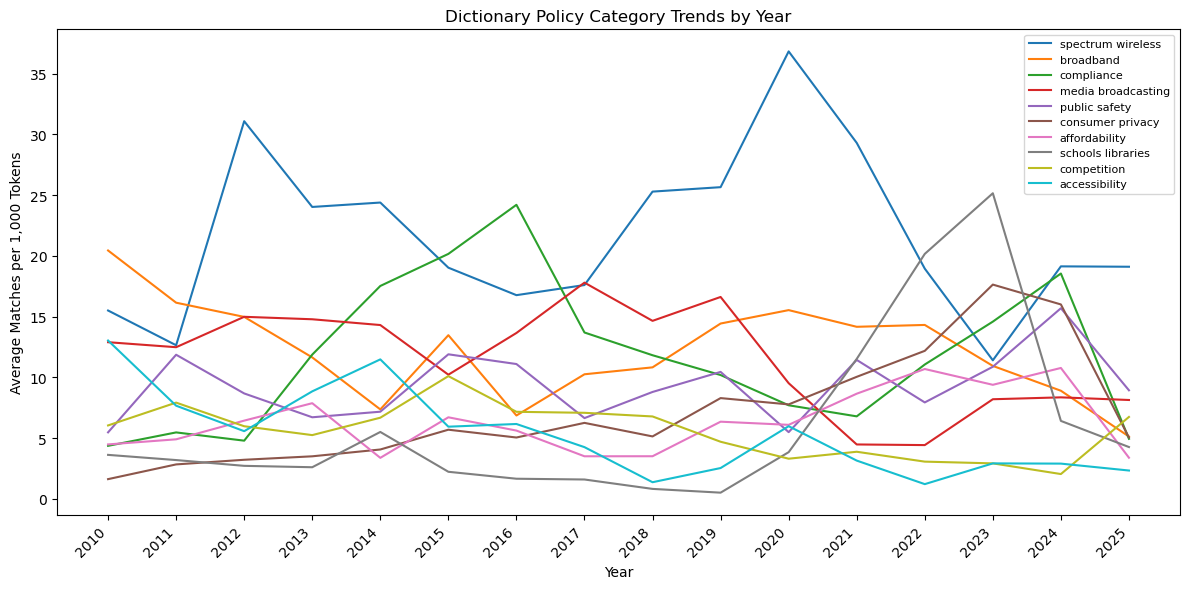

In [71]:
policy_trend_rate_cols = [f'{category}_avg_rate_per_1000_tokens' for category in policy_categories]

plot_lines(
    dictionary_policy_trend_by_year,
    'year',
    policy_trend_rate_cols,
    'Dictionary Policy Category Trends by Year',
    'Average Matches per 1,000 Tokens',
    'policy_category_trends_by_year.png',
    top_n=10
)

# 7. Topic Modeling: Baseline

## 7.1. Initial Settings

In [72]:
# Create a count vectorizer for topic modeling.
topic_count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=5,
    max_features=7000
)

# Create the document-term count matrix.
X_topic_count = topic_count_vectorizer.fit_transform(df['clean_text'].fillna(''))

# Get the vocabulary terms from the count vectorizer.
topic_terms = topic_count_vectorizer.get_feature_names_out()

In [73]:
# Create a TF-IDF vectorizer using the same vocabulary.
topic_tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    vocabulary=topic_count_vectorizer.vocabulary_,
    use_idf=True,
    norm='l2'
)

# Create the document-term TF-IDF matrix.
X_topic_tfidf = topic_tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

In [74]:
# Basic checks for the count and TF-IDF matrices.
topic_modeling_sanity_checks_dict = {
    'count_matrix_shape': str(X_topic_count.shape),
    'tfidf_matrix_shape': str(X_topic_tfidf.shape),
    'topic_vocabulary_size': len(topic_terms)
}

topic_modeling_sanity_checks = pd.DataFrame(
    topic_modeling_sanity_checks_dict.items(),
    columns=['metric', 'value']
)

save_table(topic_modeling_sanity_checks, 'topic_modeling_sanity_checks.csv')

topic_modeling_sanity_checks

,metric,value
0,count_matrix_shape,"(3073, 7000)"
1,tfidf_matrix_shape,"(3073, 7000)"
2,topic_vocabulary_size,7000


In [75]:
# Set the number of top words used for topic inspection and evaluation.
TOPIC_TOP_N_WORDS = 10

# Set the  minimum number of valid words per topic for coherence evaluation.
TOPIC_COHERENCE_MINIMUM_WORDS = 2

In [76]:
# Convert cleaned texts into token lists and remove empty lists.
topic_evaluation_tokenized_texts = (
    df['clean_text']
    .fillna('')
    .str.split()
    .tolist()
)

topic_evaluation_tokenized_texts = [
    tokens
    for tokens in topic_evaluation_tokenized_texts
    if len(tokens) > 0
]

# Create a Gensim dictionary from the tokenized texts.
topic_evaluation_dictionary = Dictionary(topic_evaluation_tokenized_texts)

# Convert tokenized texts into bag-of-words format.
topic_evaluation_corpus = [
    topic_evaluation_dictionary.doc2bow(tokens)
    for tokens in topic_evaluation_tokenized_texts
]

# Store coherence evaluation settings in a dataframe.
topic_coherence_evaluation_settings = pd.DataFrame([{
    'top_n_words': TOPIC_TOP_N_WORDS,
    'minimum_words_per_topic': TOPIC_COHERENCE_MINIMUM_WORDS,
    'n_texts_for_coherence': len(topic_evaluation_tokenized_texts),
    'coherence_dictionary_size': len(topic_evaluation_dictionary),
}])

save_table(topic_coherence_evaluation_settings, 'topic_coherence_evaluation_settings.csv')

topic_coherence_evaluation_settings

,top_n_words,minimum_words_per_topic,n_texts_for_coherence,coherence_dictionary_size
0,10,2,3073,9023


## 7.2. Define Helper Functions

In [77]:
# Transforms the model’s topic-word weights into a table
def get_topic_words(model, terms, n_top_words=TOPIC_TOP_N_WORDS):
    rows = []

    # # Loop through each topic and its word weights.
    for topic_idx, topic_weights in enumerate(model.components_):

        # Get indices of the top n words for this topic.
        top_indices = np.argsort(topic_weights)[::-1][:n_top_words]

        # Store each top word with its rank and weight.
        for rank, term_idx in enumerate(top_indices, start=1):
            rows.append({
                'topic': topic_idx,
                'rank': rank,
                'term': terms[term_idx],
                'weight': float(topic_weights[term_idx]),
            })

    # Convert the results into a dataframe.
    return pd.DataFrame(rows)

In [78]:
# Extracts top words from a topic-word table.
def extract_top_words_by_topic(
    topic_words_df,
    top_n=TOPIC_TOP_N_WORDS,
    topic_col='topic',
    rank_col='rank',
    term_col='term',
    exclude_outlier=True
):

    # Copy the topic-word table.
    words = topic_words_df.copy()

    # Remove outlier topic if requested.
    if exclude_outlier:
        
        topic_numeric = words[topic_col]
        words = words.loc[topic_numeric.ne(-1) | topic_numeric.isna()].copy()

    # Create empty dictionary to store top words by topic.
    topic_word_lists = {}

    # Process each topic separately.
    for topic, group in words.groupby(topic_col, sort=True):

        # Sort words by rank and clean term strings.
        terms = (
            group
            .sort_values(rank_col)[term_col]
            .dropna()
            .str.strip()
        )

        # Remove empty terms.
        terms = [term for term in terms if term]

        # Keep only the top n words for each topic.
        topic_word_lists[topic] = terms[:top_n]

    # Return topic-to-word-list dictionary.
    return topic_word_lists

In [79]:
# Normalizes topic scores so that the sum in each document is 1
def normalize_topic_scores(topic_matrix):

    # Calculate the total topic score for each document.
    row_sums = topic_matrix.sum(axis=1, keepdims=True)

    # Avoid division by zero for documents with no topic scores.
    row_sums[row_sums == 0] = 1

    # Convert topic scores into row-wise proportions.
    return topic_matrix / row_sums

In [80]:
# Calculates topic diversity.
def calculate_topic_diversity(topic_word_lists):

    # Flatten all topic-word lists into one list.
    top_words = [
        word
        for words in topic_word_lists.values()
        for word in words
    ]

    # Return NaN if there are no words to evaluate
    if len(top_words) == 0:
        return np.nan

    # Calculate the share of unique words among all top words.
    return len(set(top_words)) / len(top_words)

In [81]:
# Filters topics words that exist in the Gensim coherence dictionary
def valid_words_for_coherence(topic_words, dictionary):

    # Return no words if the dictionary is missing.
    if dictionary is None:
        return []

    # Create a fast lookup set of dictionary tokens.
    token_lookup = set(dictionary.token2id)

    # Create empty list of valid words
    valid_words = []
    seen_words = set()

    # Check each topic word.
    for term in topic_words:

        # Remove extra spaces.
        term = term.strip()

        # Skip empty terms.
        if not term:
            continue

        # Keep the full term if it exists in the dictionary.
        if term in token_lookup:
            candidate_words = [term]
        # Otherwise, split phrases into individual words.
        else:
            candidate_words = term.replace('_', ' ').split()

        # Check each candidate word.
        for candidate in candidate_words:

            # Remove extra spaces.
            candidate = candidate.strip()

            # Keep only valid and non-duplicate words.
            if candidate in token_lookup and candidate not in seen_words:
                valid_words.append(candidate)
                seen_words.add(candidate)

    # Return words that can be used for coherence.
    return valid_words

In [82]:
# Calculate topic coherence.
def calculate_topic_coherence(
    topic_word_lists,
    tokenized_texts,
    dictionary,
    corpus=None,
    coherence='c_v',
    minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
):

    # Return NaN if required coherence inputs are missing.
    if dictionary is None or len(tokenized_texts) == 0:
        return np.nan

    # Create empty list to store topics with enough valid words.
    valid_topics = []

    # Validate topic words against the dictionary.
    for topic_words in topic_word_lists.values():
        
        valid_words = valid_words_for_coherence(topic_words, dictionary)

        # Keep only topics with enough valid words.
        if len(valid_words) >= minimum_words:
            valid_topics.append(valid_words)

    # Return NaN if no topics can be evaluated.
    if len(valid_topics) == 0:
        return np.nan
    
    try:
        # Use corpus-based coherence for u_mass.
        if coherence == 'u_mass':

            # Create a corpus if one was not provided.
            if corpus is None:
                corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_texts]

            # Build the coherence model using the corpus.
            coherence_model = CoherenceModel(
                topics=valid_topics,
                corpus=corpus,
                dictionary=dictionary,
                coherence=coherence,
                processes=1
            )

        # Use text-based coherence for c_v and other metrics.
        else:
            # Build the coherence model using tokenized texts.
            coherence_model = CoherenceModel(
                topics=valid_topics,
                texts=tokenized_texts,
                dictionary=dictionary,
                coherence=coherence,
                processes=1
            )

        # Calculate and return the coherence score.
        return float(coherence_model.get_coherence())

    # Return NaN if coherence calculation fails.
    except Exception:
        return np.nan

In [83]:
def topic_redundancy(topic_words_df, top_n=TOPIC_TOP_N_WORDS):

    # Create one set of top words for each topic.
    topic_sets = [
        set(group['term'])
        for _, group in topic_words_df[topic_words_df['rank'] <= top_n].groupby('topic')
    ]

    # Return zero redundancy if fewer than two topics exist.
    if len(topic_sets) < 2:
        return 0.0, 0

    # Create empty list to store pairwise topic similarities.
    similarities = []
    # Set to zero to count topic pairs with high overlap.
    high_redundancy_pairs = 0

    # Compare every pair of topics once.
    for i in range(len(topic_sets)):
        for j in range(i + 1, len(topic_sets)):

            # Count all unique words across the two topics.
            union_size = len(topic_sets[i] | topic_sets[j])
            # Calculate similarity between the two topics.
            similarity = len(topic_sets[i] & topic_sets[j]) / union_size if union_size else 0
            # Store the similarity score.
            similarities.append(similarity)

            # Count highly redundant topic pairs.
            if similarity >= 0.5:
                high_redundancy_pairs += 1

    # Return average redundancy and number of highly redundant pairs.
    return float(np.mean(similarities)), high_redundancy_pairs

In [84]:
# Measures how strongly topic-modeling results align with dictionary-based policy categories.
def dictionary_topic_alignment(dataframe, policy_rate_cols, topic_cols):

    # Calculate correlations between policy-rate columns and topic columns.
    correlation = dataframe[policy_rate_cols + topic_cols].corr().loc[policy_rate_cols, topic_cols]

    # Return the average of strongest topic alignment for each policy category.
    return correlation.max(axis=1).mean()

In [85]:
def evaluate_nmf_topic_count(policy_rate_cols, n_topics):

    # Create an NMF model with the selected number of topics.
    model = NMF(
        n_components=n_topics, 
        init='nndsvda', 
        random_state=RANDOM_STATE, 
        max_iter=400
    )

    # Fit the model and get document-topic scores.
    doc_topic = model.fit_transform(X_topic_tfidf)

    # Normalize topic scores within each document.
    doc_topic_normalized = normalize_topic_scores(doc_topic)

    # Create column names for topic scores.
    topic_cols = [f'topic_{idx}' for idx in range(n_topics)]

    # Combine policy-rate columns and topic-score columns.
    temp_df = pd.concat(
        [df[policy_rate_cols].reset_index(drop=True), 
         pd.DataFrame(doc_topic_normalized, columns=topic_cols)],
        axis=1,
    )

    # Extract top words for each topic.
    topic_words = get_topic_words(model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate average topic prevalence.
    prevalence = doc_topic_normalized.mean(axis=0)

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(topic_words)

    # Calculate alignment between dictionary categories and topics.
    policy_topic_alignment = dictionary_topic_alignment(temp_df, policy_rate_cols, topic_cols)
    
    return {
        'model': 'NMF',
        'n_topics': n_topics,
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'reconstruction_error': model.reconstruction_err_,
        'avg_max_document_topic_score': doc_topic_normalized.max(axis=1).mean(),
        'min_topic_prevalence': prevalence.min(),
        'max_topic_prevalence': prevalence.max(),
        'low_prevalence_topics': int((prevalence < 0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,
        'avg_best_policy_topic_alignment': policy_topic_alignment,
    }, topic_words.assign(n_topics=n_topics)

In [86]:
def evaluate_lda_topic_count(policy_rate_cols, n_topics):

    # Create an LDA model with the selected number of topics.
    model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method='batch',
        max_iter=15,
        n_jobs=-1,
    )

    # Fit the model and get document-topic probabilities.
    doc_topic = model.fit_transform(X_topic_count)

    # Create column names for topic scores.
    topic_cols = [f'topic_{idx}' for idx in range(n_topics)]

    # Combine policy-rate columns and topic-score columns.
    temp_df = pd.concat(
        [df[policy_rate_cols].reset_index(drop=True), 
         pd.DataFrame(doc_topic, columns=topic_cols)],
        axis=1,
    )

    # Extract top words for each topic.
    topic_words = get_topic_words(model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate average topic prevalence.
    prevalence = doc_topic.mean(axis=0)

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(topic_words)

    # Calculate alignment between dictionary categories and topics.
    policy_topic_alignment = dictionary_topic_alignment(temp_df, policy_rate_cols, topic_cols)

    return {
        'model': 'LDA',
        'n_topics': n_topics,
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'perplexity': model.perplexity(X_topic_count),
        'log_likelihood': model.score(X_topic_count),
        'avg_max_document_topic_probability': doc_topic.max(axis=1).mean(),
        'min_topic_prevalence': prevalence.min(),
        'max_topic_prevalence': prevalence.max(),
        'low_prevalence_topics': int((prevalence < 0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,
        'avg_best_policy_topic_alignment': policy_topic_alignment,
    }, topic_words.assign(n_topics=n_topics)

In [87]:
def topic_trend_by_period(dataframe, topic_cols, period_col):

    # Calculate average topic scores by period.
    trend = dataframe.groupby(period_col, sort=True)[topic_cols].mean().reset_index()

    # Count the number of documents by period.
    document_counts = dataframe.groupby(period_col, sort=True).size().rename('n_documents').reset_index()

    # Combine document counts with average topic scores.
    return document_counts.merge(trend, on=period_col, how='left')

In [88]:
def representative_documents(dataframe, topic_cols, model_name, n_documents=5):

    # Create empty list to store representative document rows.
    rows = []

    # Process each topic column.
    for topic_col in topic_cols:

        # Extract the topic ID from the column name.
        topic_id = int(topic_col.split('_')[-1])

        # Select documents with the highest topic probabilities.
        top_documents = dataframe.sort_values(topic_col, ascending=False).head(n_documents)

        # Store the top documents for the topic.
        for rank, (_, row) in enumerate(top_documents.iterrows(), start=1):
            
            rows.append({
                'model': model_name,
                'topic': topic_id,
                'rank': rank,
                'topic_probability': row[topic_col],
                'filename': row['filename'],
                'title': row['page_title'],
                'year': row['year'],
                'dominant_policy_category': row['dominant_policy_category'],
                'dominant_policy_category_score': row['dominant_policy_category_score'],
                'matched_dictionary_terms': row['all_policy_matched_terms'],
                'text_preview': str(row.get('body_text', ''))[:700].replace('\n', ' '),
            })

    # Convert the rows into a dataframe.
    return pd.DataFrame(rows)

## 7.3. (1) NMF Topic Modeling

### 7.3.1. Evaluate Number of Topics

In [89]:
# Define candidate topic numbers to evaluate.
candidate_topic_counts = [5, 8, 10, 12, 15, 18, 20, 25]

# Create empty list to store NMF evaluation results and topic words for each candidate model.
nmf_evaluation_rows = []
nmf_candidate_topic_words = []

# Evaluate NMF models with different topic counts.
for n_topics in tqdm(candidate_topic_counts):
    evaluation_row, topic_words = evaluate_nmf_topic_count(policy_rate_cols, n_topics)
    nmf_evaluation_rows.append(evaluation_row)
    nmf_candidate_topic_words.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
nmf_topic_number_evaluation = pd.DataFrame(nmf_evaluation_rows)
nmf_candidate_topic_words = pd.concat(nmf_candidate_topic_words, ignore_index=True)

save_table(nmf_topic_number_evaluation, 'nmf_topic_number_evaluation.csv')
save_table(nmf_candidate_topic_words, 'nmf_candidate_topic_words.csv')

  0%|          | 0/8 [00:00<?, ?it/s]

In [90]:
nmf_topic_number_evaluation

,model,n_topics,topic_diversity_top10,coherence_c_v_top10,reconstruction_error,avg_max_document_topic_score,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,avg_best_policy_topic_alignment
0,NMF,5,0.980000,0.684881,51.995424,0.655979,0.108401,0.296206,0,0.005263,0,0.332876
1,NMF,8,0.950000,0.741589,51.027256,0.632351,0.068988,0.263758,0,0.007519,0,0.473062
2,NMF,10,0.920000,0.735609,50.515230,0.606394,0.059634,0.166199,0,0.010656,0,0.541077
3,NMF,12,0.916667,0.732114,50.082477,0.593739,0.049992,0.125957,0,0.008861,0,0.591683
4,NMF,15,0.913333,0.748117,49.441230,0.584736,0.042331,0.149505,0,0.007686,0,0.658823
5,NMF,18,0.911111,0.750883,48.959753,0.560864,0.026868,0.109092,0,0.007384,0,0.704047
6,NMF,20,0.905000,0.729300,48.657538,0.542643,0.026240,0.083494,0,0.007295,0,0.738556
7,NMF,25,0.864000,0.725835,48.012939,0.531326,0.019313,0.087075,0,0.007723,0,0.739124


In [91]:
nmf_candidate_topic_words

,topic,rank,term,weight,n_topics
0,0,1,spectrum,1.137020,5
1,0,2,auction,1.031016,5
2,0,3,broadband,0.802525,5
3,0,4,rural,0.656808,5
4,0,5,band,0.621492,5
...,...,...,...,...,...
1125,24,6,competition,0.321776,25
1126,24,7,speed,0.307698,25
1127,24,8,carrier,0.301507,25
1128,24,9,requirement,0.292534,25


### 7.3.2. Analysis Results

In [92]:
# Set the final number of NMF topics.
NMF_TOPIC_COUNT = 10

# Create the final NMF model.
nmf_model = NMF(
    n_components=NMF_TOPIC_COUNT, 
    init='nndsvda', 
    random_state=RANDOM_STATE, 
    max_iter=500
)

In [93]:
# Fit the model and get raw document-topic scores.
nmf_doc_topic_raw = nmf_model.fit_transform(X_topic_tfidf)

# Normalize document-topic scores.
nmf_doc_topic = normalize_topic_scores(nmf_doc_topic_raw)

# Create NMF topic-score column names.
nmf_topic_cols = [f'nmf_topic_{idx}' for idx in range(NMF_TOPIC_COUNT)]

# Add NMF topic scores to the main dataframe.
for idx, col in enumerate(nmf_topic_cols):
    df[col] = nmf_doc_topic[:, idx]

In [94]:
# Assign the dominant NMF topic and topic score for each document.
df['dominant_nmf_topic'] = np.argmax(nmf_doc_topic, axis=1)

df['dominant_nmf_topic_score'] = np.max(nmf_doc_topic, axis=1)

In [95]:
# Extract top words and representative documents for each final NMF topic.
nmf_topic_words = get_topic_words(nmf_model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)
nmf_representative_documents = representative_documents(df, nmf_topic_cols, 'NMF')

save_table(nmf_topic_words, 'nmf_topic_words.csv')
save_table(nmf_representative_documents, 'nmf_representative_documents.csv')

In [96]:
nmf_topic_words

,topic,rank,term,weight
0,0,1,consumer,1.430361
1,0,2,service,0.903260
2,0,3,customer,0.771462
3,0,4,company,0.762379
4,0,5,charge,0.733580
...,...,...,...,...
95,9,6,eas,0.459011
96,9,7,broadcaster,0.448970
97,9,8,programming,0.420831
98,9,9,request,0.353207


In [97]:
nmf_representative_documents

,model,topic,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,NMF,0,1,1.000000,131217_FCC_Proposes_$3.56M_Fine_Against_CTI_in...,FCC Proposes $3.56M Fine Against CTI in Crammi...,2013,compliance,43.956044,accessibility: disability | compliance: enforc...,The Federal Communications Commission has prop...
1,NMF,0,2,1.000000,141008_ATT_To_Pay_$105_Million_To_Resolve_Wire...,AT&T To Pay $105 Million To Resolve Wireless C...,2014,compliance,80.168776,compliance: settlement (7); enforcement (4); e...,The Federal Communications Commission today an...
2,NMF,0,3,1.000000,"190813_FCC_Reaches_$550,000_Cramming_Settlemen...","FCC Reaches $550,000 Cramming Settlement with ...",2019,compliance,86.092715,compliance: settlement (5); enforcement (3); i...,The Federal Communications Commission’s Enforc...
3,NMF,0,4,1.000000,"140714_FCC_to_Fine_Optic_$7.62M_for_Cramming,_...","FCC to Fine Optic $7.62M for Cramming, Slammin...",2014,compliance,39.024390,compliance: enforcement (5); violation; penalt...,The Federal Communications Commission plans to...
4,NMF,0,5,1.000000,141219_T-Mobile_to_Pay_$90_Million_to_Settle_C...,T-Mobile to Pay $90 Million to Settle Cramming...,2014,compliance,60.240964,compliance: settlement (8); enforcement (5); i...,The Federal Communications Commission today an...
5,NMF,1,1,1.000000,230726_FCC_Announces_Nearly_$55_Million_in_Eme...,FCC Announces Nearly $55 Million in Emergency ...,2023,schools_libraries,184.873950,broadband: broadband | schools_libraries: stud...,The Federal Communications Commission today an...
6,NMF,1,2,1.000000,230823_FCC_Announces_$68_Million_in_Emergency_...,FCC Announces $68 Million in Emergency Connect...,2023,schools_libraries,178.861789,broadband: broadband | schools_libraries: stud...,The Federal Communications Commission today an...
7,NMF,1,3,1.000000,230809_FCC_Announces_$46_Million_in_Emergency_...,FCC Announces $46 Million in Emergency Connect...,2023,schools_libraries,186.991870,broadband: broadband | schools_libraries: stud...,The Federal Communications Commission today an...
8,NMF,1,4,1.000000,230920_FCC_Announces_Almost_$41_Million_in_Eme...,FCC Announces Almost $41 Million in Emergency ...,2023,schools_libraries,178.861789,broadband: broadband (2) | schools_libraries: ...,The Federal Communications Commission today an...
9,NMF,1,5,1.000000,230906_FCC_Announces_$7_Million_in_Emergency_C...,FCC Announces $7 Million in Emergency Connecti...,2023,schools_libraries,181.818182,broadband: broadband (2) | schools_libraries: ...,The Federal Communications Commission today an...


### 7.3.3. Trends by Year, Quarter and Month

In [98]:
# Calculate NMF topic trends by year, quarter and month.
nmf_topic_trend_by_year = topic_trend_by_period(df, nmf_topic_cols, 'year')

nmf_topic_trend_by_quarter = topic_trend_by_period(df, nmf_topic_cols, 'quarter')

nmf_topic_trend_by_month = topic_trend_by_period(df, nmf_topic_cols, 'month')

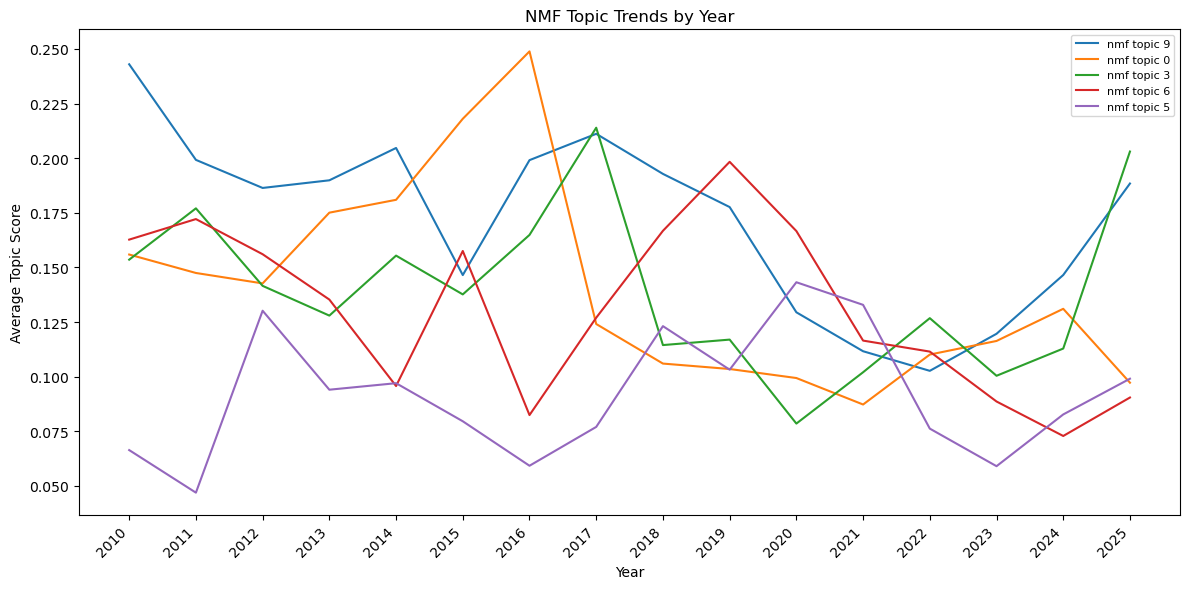

In [99]:
# Plot the top NMF topic trends by year.
plot_lines(
    nmf_topic_trend_by_year, 
    'year', 
    nmf_topic_cols, 
    'NMF Topic Trends by Year', 
    'Average Topic Score',
    'nmp_topic_trends_by_year',
    top_n=5
)

## 7.4. (2) LDA Topic Modeling

### 7.4.1. Evaluate Number of Topics

In [100]:
# Create empty list to store LDA evaluation results and topic words for each candidate model.
lda_evaluation_rows = []
lda_candidate_topic_words = []

# Evaluate LDA models with different topic counts.
for n_topics in tqdm(candidate_topic_counts):
    evaluation_row, topic_words = evaluate_lda_topic_count(policy_rate_cols, n_topics)
    lda_evaluation_rows.append(evaluation_row)
    lda_candidate_topic_words.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
lda_topic_number_evaluation = pd.DataFrame(lda_evaluation_rows)
lda_candidate_topic_words = pd.concat(lda_candidate_topic_words, ignore_index=True)

save_table(lda_topic_number_evaluation, 'lda_topic_number_evaluation.csv')
save_table(lda_candidate_topic_words, 'lda_candidate_topic_words.csv')

  0%|          | 0/8 [00:00<?, ?it/s]

In [101]:
lda_topic_number_evaluation

,model,n_topics,topic_diversity_top10,coherence_c_v_top10,perplexity,log_likelihood,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,avg_best_policy_topic_alignment
0,LDA,5,0.880000,0.520059,1588.351798,-4.537803e+06,0.754389,0.088941,0.259300,0,0.048538,0,0.374776
1,LDA,8,0.800000,0.576331,1476.307138,-4.492765e+06,0.676083,0.047239,0.205631,0,0.039511,0,0.445415
2,LDA,10,0.800000,0.569864,1361.810516,-4.443062e+06,0.658229,0.031976,0.196323,0,0.039497,0,0.489860
3,LDA,12,0.766667,0.561705,1293.997290,-4.411614e+06,0.669963,0.021171,0.179307,0,0.040429,0,0.541777
4,LDA,15,0.800000,0.554755,1223.950885,-4.377350e+06,0.662050,0.020050,0.142965,0,0.027008,0,0.561505
5,LDA,18,0.761111,0.590717,1187.210835,-4.358586e+06,0.647503,0.019854,0.138106,0,0.032618,0,0.585398
6,LDA,20,0.765000,0.596297,1166.188822,-4.347587e+06,0.641309,0.019205,0.127794,0,0.028640,0,0.590656
7,LDA,25,0.696000,0.604034,1113.676603,-4.319220e+06,0.620110,0.014352,0.101739,0,0.030640,0,0.638886


In [102]:
lda_candidate_topic_words

,topic,rank,term,weight,n_topics
0,0,1,service,1719.109040,5
1,0,2,provide,1072.153490,5
2,0,3,station,997.497499,5
3,0,4,public,912.112778,5
4,0,5,support,822.229572,5
...,...,...,...,...,...
1125,24,6,provider,404.512833,25
1126,24,7,income,367.293127,25
1127,24,8,low,335.146535,25
1128,24,9,eligible,315.647315,25


### 7.4.2. Analysis Results

In [103]:
# Set the final number of LDA topics.
LDA_TOPIC_COUNT = 10

# Create the final LDA model.
lda_model = LatentDirichletAllocation(
    n_components=LDA_TOPIC_COUNT,
    random_state=RANDOM_STATE,
    learning_method='batch',
    max_iter=25,
    n_jobs=-1,
)

In [104]:
# Fit the model and get document-topic probabilities.
lda_doc_topic = lda_model.fit_transform(X_topic_count)

# Create LDA topic-probabilities column names.
lda_topic_cols = [f'lda_topic_{idx}' for idx in range(LDA_TOPIC_COUNT)]

# Add LDA topic probabilities to the main dataframe.
for idx, col in enumerate(lda_topic_cols):
    df[col] = lda_doc_topic[:, idx]

In [105]:
# Assign the dominant LDA topic and topic probability for each document.
df['dominant_lda_topic'] = np.argmax(lda_doc_topic, axis=1)

df['dominant_lda_topic_probability'] = np.max(lda_doc_topic, axis=1)

In [106]:
# Extract top words and representative documents for each final LDA topic.
lda_topic_words = get_topic_words(lda_model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)
lda_representative_documents = representative_documents(df, lda_topic_cols, 'LDA')

save_table(lda_topic_words, 'lda_topic_words.csv')
save_table(lda_representative_documents, 'lda_representative_documents.csv')

In [107]:
lda_topic_words

,topic,rank,term,weight
0,0,1,school,1135.253175
1,0,2,support,918.130848
2,0,3,program,885.982719
3,0,4,funding,845.591441
4,0,5,library,810.099939
...,...,...,...,...
95,9,6,company,625.524129
96,9,7,number,610.533805
97,9,8,phone,586.642027
98,9,9,complaint,545.171189


In [108]:
lda_representative_documents

,model,topic,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,LDA,0,1,0.995871,230712_FCC_Announces_Over_$13.9_Million_in_Eme...,FCC Announces Over $13.9 Million in Emergency ...,2023,schools_libraries,201.550388,broadband: broadband | schools_libraries: stud...,The Federal Communications Commission today an...
1,LDA,0,2,0.995852,220810_FCC_Announces_Nearly_$68_Million_in_Eme...,FCC Announces Nearly $68 Million in Emergency ...,2022,schools_libraries,162.601626,broadband: internet access; broadband | school...,The Federal Communications Commission today an...
2,LDA,0,3,0.995794,230628_FCC_Announces_Over_$29_Million_in_Emerg...,FCC Announces Over $29 Million in Emergency Co...,2023,schools_libraries,188.976378,broadband: broadband | schools_libraries: stud...,The Federal Communications Commission today an...
3,LDA,0,4,0.995794,230920_FCC_Announces_Almost_$41_Million_in_Eme...,FCC Announces Almost $41 Million in Emergency ...,2023,schools_libraries,178.861789,broadband: broadband (2) | schools_libraries: ...,The Federal Communications Commission today an...
4,LDA,0,5,0.995774,220824_FCC_Announces_Nearly_$42_Million_in_Eme...,FCC Announces Nearly $42 Million in Emergency ...,2022,schools_libraries,165.289256,broadband: internet access; broadband | school...,The Federal Communications Commission today an...
5,LDA,1,1,0.997239,100625_FCC_Releases_New_Local_Telephone_Compet...,FCC Releases New Local Telephone Competition Data,2010,broadband,23.437500,broadband: broadband (5); broadband_internet |...,The Federal Communications Commission for the ...
6,LDA,1,2,0.997178,100903_FCC_Releases_New_Local_Telephone_Compet...,FCC Releases New Local Telephone Competition Data,2010,broadband,23.809524,broadband: broadband (5); broadband_internet |...,The Federal Communications Commission today re...
7,LDA,1,3,0.996538,110111_FCC_Releases_New_Local_Telephone_Compet...,FCC Releases New Local Telephone Competition Data,2011,broadband,15.000000,broadband: broadband (3) | competition: compet...,The Federal Communications Commission today re...
8,LDA,1,4,0.996414,150805_Windstream_Takes_$175M_Connect_America_...,Windstream Takes $175M Connect America Offer T...,2015,broadband,95.808383,broadband: broadband (12); rural area; broadba...,"D.C. (Aug. 5, 2015) Windstream Communications ..."
9,LDA,1,5,0.996385,150827_ATT_Accepts_$428_M_From_Connect_America...,AT&T Accepts $428 M From Connect America Fund ...,2015,broadband,88.757396,broadband: broadband (12); rural area; broadba...,"AT&T, Inc. has accepted $427,706,650 in annual..."


### 7.4.3. Trends by Year, Quarter and Month

In [109]:
# Calculate LDA topic trends by year, quarter and month.
lda_topic_trend_by_year = topic_trend_by_period(df, lda_topic_cols, 'year')

lda_topic_trend_by_quarter = topic_trend_by_period(df, lda_topic_cols, 'quarter')

lda_topic_trend_by_month = topic_trend_by_period(df, lda_topic_cols, 'month')

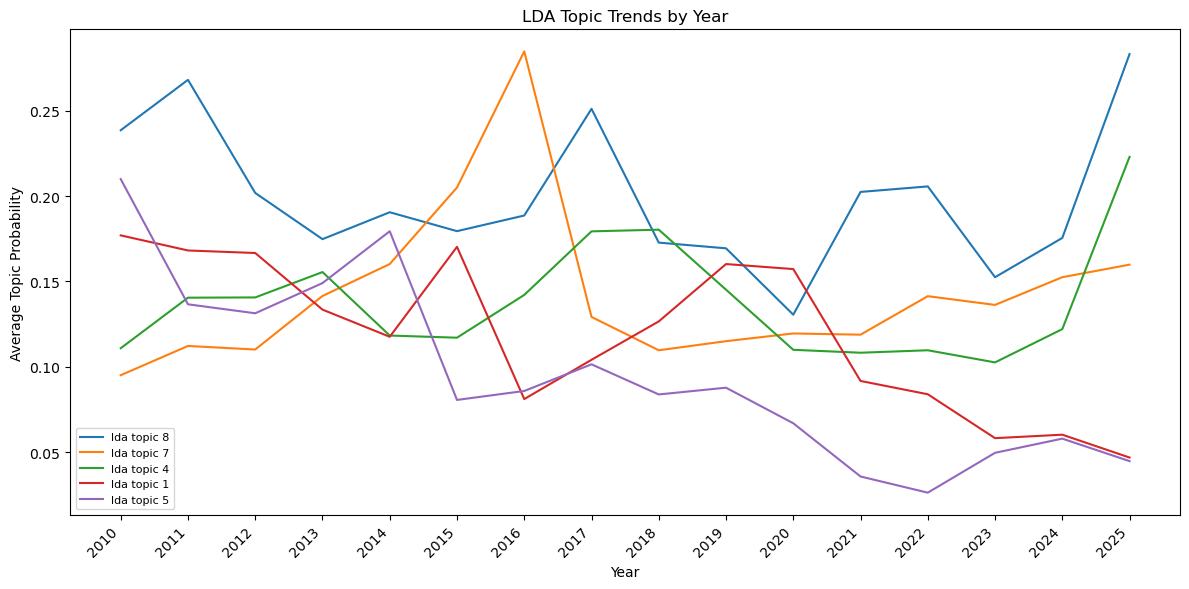

In [110]:
# Plot the top LDA topic trends by year.
plot_lines(
    lda_topic_trend_by_year, 
    'year', 
    lda_topic_cols, 
    'LDA Topic Trends by Year', 
    'Average Topic Probability',
    'lda_topic_trends_by_year.png',
    top_n=5
)

# 8. Topic Modeling: BERTopic

## 8.1. Prepare Text for BERTopic

In [111]:
# Select the text column for BERTopic.
BERTOPIC_TEXT_COL = 'body_text'

# Set the minimum number of tokens required for BERTopic input.
BERTOPIC_MIN_TOKEN_COUNT = 20

In [112]:
# Clean the selected text column.
bertopic_text = df[BERTOPIC_TEXT_COL].fillna('').astype(str).str.strip()

# Count words in each document
bertopic_token_counts = bertopic_text.str.split().map(len)

# Keep only non-empty documents with at least the minimum token count.
bertopic_valid_mask = bertopic_text.ne('') & bertopic_token_counts.ge(BERTOPIC_MIN_TOKEN_COUNT)

In [113]:
# Convert valid documents into a list for BERTopic.
bertopic_docs = bertopic_text.loc[bertopic_valid_mask].tolist()

# Store the original dataframe index of documents used in BERTopic.
bertopic_doc_index = df.index[bertopic_valid_mask]

# Store token counts only for documents used in BERTopic.
bertopic_doc_token_counts = bertopic_token_counts.loc[bertopic_valid_mask]

In [114]:
# Create a summary of the BERTopic input data.
bertopic_input_summary = pd.DataFrame([{
    'total_documents': int(len(df)),
    'documents_used_for_bertopic': int(bertopic_valid_mask.sum()),
    'minimum_token_threshold': BERTOPIC_MIN_TOKEN_COUNT,
    'selected_text_column': BERTOPIC_TEXT_COL,
    'min_word_count_included': int(bertopic_doc_token_counts.min()),
    'median_word_count_included': float(bertopic_doc_token_counts.median()),
    'max_word_count_included': int(bertopic_doc_token_counts.max()),
}])

save_table(bertopic_input_summary, 'bertopic_input_summary.csv')

bertopic_input_summary

,total_documents,documents_used_for_bertopic,minimum_token_threshold,selected_text_column,min_word_count_included,median_word_count_included,max_word_count_included
0,3073,3073,20,body_text,25,350.0,8115


## 8.2. Initial Settings

In [115]:
# Load the selected SentenceTransformer model.
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [116]:
# Create a BERTopic model with a chosen minimum topic size.
def make_bertopic_model(min_topic_size, verbose=False):

    return BERTopic(
        # Use the loaded embedding model.
        embedding_model=embedding_model,

        # Reduce embedding dimensions before clustering.
        umap_model=UMAP(
            n_neighbors=15,
            n_components=5,
            min_dist=0.0,
            metric='cosine',
            random_state=RANDOM_STATE
        ),

        # Cluster documents into topics.
        hdbscan_model=HDBSCAN(
            min_cluster_size=min_topic_size,
            min_samples=5,
            metric='euclidean',
            prediction_data=True
        ),

        # Extract topic words using custom tokenization.
        vectorizer_model=CountVectorizer(
            tokenizer=document_to_tokens,
            token_pattern=None,
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.85
        ),

        # Set the number of top words per topic.
        top_n_words=TOPIC_TOP_N_WORDS,

        # Calculate document-topic probabilities.
        calculate_probabilities=True,

        # Control progress messages.
        verbose=verbose
    )


In [117]:
# Create embeddings for valid BERTopic documents.
bertopic_embeddings = embedding_model.encode(
    bertopic_docs,
    show_progress_bar=True
)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

## 8.3. Define Helper Functions

In [118]:
def extract_bertopic_document_probabilities(probabilities, topics):

    # Get the highest topic probability for each document.
    document_probabilities = np.nanmax(np.asarray(probabilities), axis=1)

    # Replace probabilities for outlier documents with NaN.
    return (
        pd.Series(document_probabilities)
        .where(pd.Series(topics).ne(-1), np.nan)
        .to_numpy()
    )

In [119]:
def get_bertopic_topic_words(topic_model, topic_ids, n_top_words=TOPIC_TOP_N_WORDS):

    # Create empty list to store topic-word rows.
    rows = []

    # Loop through each selected topic.
    for topic_id in topic_ids:

        # Get topic words, or use an empty list if none exist.
        topic_words = topic_model.get_topic(topic_id) or []

        # Keep only the top words.
        topic_words = topic_words[:n_top_words]

        # Add each topic word with its rank and weight.
        for rank, (term, weight) in enumerate(topic_words, start=1):

            rows.append({
                'topic': topic_id,
                'rank': rank,
                'term': term,
                'weight': float(weight),
            })

    # Return the result as a DataFrame.
    return pd.DataFrame(rows, columns=['topic', 'rank', 'term', 'weight'])

In [120]:
def evaluate_bertopic_min_topic_size(min_topic_size):

    # Create a BERTopic model with the selected minimum topic size.
    model = make_bertopic_model(min_topic_size)

    # Fit BERTopic using precomputed document embeddings.
    candidate_topics, candidate_probabilities = model.fit_transform(
        bertopic_docs,
        embeddings=bertopic_embeddings
    )

    # Get the topic summary table.
    topic_info = model.get_topic_info().copy()

    # Extract valid topic IDs, excluding the outlier topic.
    topic_ids = sorted(topic_info.loc[topic_info['Topic'].ne(-1), 'Topic'].astype(int))

    # Extract top words for each valid topic.
    topic_words = get_bertopic_topic_words(model, topic_ids)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words, 
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Store assigned topic IDs as a pandas Series.
    assigned_topics = pd.Series(candidate_topics)

    # Count documents assigned to each non-outlier topic.
    non_outlier_topic_counts = assigned_topics.loc[assigned_topics.ne(-1)].value_counts().sort_index()

    # Calculate topic shares among all BERTopic input documents.
    non_outlier_topic_shares = non_outlier_topic_counts / len(assigned_topics)

    # Extract each document's strongest topic probability.
    document_probabilities = pd.Series(
        extract_bertopic_document_probabilities(candidate_probabilities, candidate_topics)
    )

    # Prepare policy dictionary scores for the same documents used by BERTopic.
    candidate_alignment_df = df.loc[bertopic_doc_index, policy_rate_cols].reset_index(drop=True).copy()

    # Convert BERTopic probabilities to a NumPy array.
    candidate_prob_matrix = np.asarray(candidate_probabilities)
    
    # Check that BERTopic returned topic probabilities for all topics.
    if candidate_prob_matrix.ndim != 2:
        raise ValueError(
            'BERTopic probabilities are not a 2D topic-probability matrix.'
        )
    
    # Create topic probability column names.
    candidate_topic_prob_cols = [f'topic_{topic_id}' for topic_id in topic_ids]
    
    # Add one probability column for each BERTopic topic.
    for topic_id, topic_col in zip(topic_ids, candidate_topic_prob_cols):
        candidate_alignment_df[topic_col] = candidate_prob_matrix[:, topic_id]
    
    # Compare BERTopic topic probabilities with dictionary-based policy rates.
    policy_topic_alignment = (
        dictionary_topic_alignment(candidate_alignment_df, policy_rate_cols, candidate_topic_prob_cols)
        if candidate_topic_prob_cols else np.nan
    )

    return {
        'model': 'BERTopic',
        'min_topic_size': min_topic_size,
        'n_topics': len(topic_ids),
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'avg_max_document_topic_probability': document_probabilities.mean(),
        'min_topic_prevalence': non_outlier_topic_shares.min(),
        'max_topic_prevalence': non_outlier_topic_shares.max(),
        'low_prevalence_topics': int(non_outlier_topic_shares.lt(0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,
        'avg_best_policy_topic_alignment': policy_topic_alignment,
        'n_outlier_documents': int(assigned_topics.eq(-1).sum()),
        'outlier_share': assigned_topics.eq(-1).mean(),
        'max_valid_topic_size': non_outlier_topic_counts.max(),
        'min_valid_topic_size': non_outlier_topic_counts.min(),
        'median_valid_topic_size': non_outlier_topic_counts.median(),
    }, topic_words.assign(min_topic_size=min_topic_size)

In [125]:
def make_bertopic_topic_label_map(topic_model):

    # Get BERTopic's topic summary table.
    topic_info = topic_model.get_topic_info()

    # Map each topic ID to a readable label.
    return {
        topic_id: 'Outlier topic' if topic_id == -1 else topic_name
        for topic_id, topic_name in zip(topic_info['Topic'], topic_info['Name'])
    }

## 8.4. Evaluate Minimum Topic Size

In [121]:
# Define candidate minimum topic sizes for BERTopic.
candidate_bertopic_min_topic_sizes = [40, 60, 80, 100, 120]

# Keep only candidate values that are not larger than the number of documents.
valid_candidate_bertopic_min_topic_sizes = [
    min_topic_size
    for min_topic_size in candidate_bertopic_min_topic_sizes
    if min_topic_size <= len(bertopic_docs)
]

In [122]:
# Create empty list to store BERTopic evaluation results and topic words for each candidate model.
bertopic_min_topic_size_evaluation_rows = []
bertopic_candidate_topic_word_tables = []

# Evaluate BERTopic models with different minimum topic sizes.
for min_topic_size in tqdm(valid_candidate_bertopic_min_topic_sizes):
    evaluation_row, topic_words = evaluate_bertopic_min_topic_size(min_topic_size)
    bertopic_min_topic_size_evaluation_rows.append(evaluation_row)
    bertopic_candidate_topic_word_tables.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
bertopic_min_topic_size_evaluation = pd.DataFrame(bertopic_min_topic_size_evaluation_rows)
bertopic_candidate_topic_words = pd.concat(
    bertopic_candidate_topic_word_tables,
    ignore_index=True
)

save_table(bertopic_min_topic_size_evaluation, 'bertopic_min_topic_size_evaluation.csv')
save_table(bertopic_candidate_topic_words, 'bertopic_candidate_topic_words.csv')

  0%|          | 0/5 [00:00<?, ?it/s]

In [123]:
bertopic_min_topic_size_evaluation

,model,min_topic_size,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,avg_best_policy_topic_alignment,n_outlier_documents,outlier_share,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size
0,BERTopic,40,19,0.957895,0.666125,0.612335,0.013667,0.202083,0,0.002531,0,0.541016,331,0.107712,621,42,97.0
1,BERTopic,60,15,0.973333,0.628377,0.631559,0.021803,0.202083,0,0.002061,0,0.551635,387,0.125936,621,67,143.0
2,BERTopic,80,12,0.983333,0.623656,0.662835,0.027660,0.202083,0,0.001684,0,0.511127,454,0.147738,621,85,188.0
3,BERTopic,100,10,0.980000,0.668558,0.623564,0.037097,0.202083,0,0.002469,0,0.485333,296,0.096323,621,114,242.0
4,BERTopic,120,8,0.950000,0.598863,0.713522,0.046534,0.273999,0,0.007728,0,0.410468,315,0.102506,842,143,242.0


In [124]:
bertopic_candidate_topic_words

,topic,rank,term,weight,min_topic_size
0,0,1,spectrum,0.059594,40
1,0,2,band,0.045540,40
2,0,3,auction,0.033564,40
3,0,4,open meeting,0.029020,40
4,0,5,ghz,0.026636,40
...,...,...,...,...,...
635,7,6,cvaa,0.064749,120
636,7,7,hearing,0.060070,120
637,7,8,video programming,0.054052,120
638,7,9,asl,0.051107,120


## 8.5. Analysis Results

### 8.5.1. Fit Selected BERTopic Model

In [126]:
# Set the final minimum topic size for BERTopic.
BERTOPIC_MIN_TOPIC_SIZE = 80

In [127]:
# Create the final BERTopic model.
bertopic_model = make_bertopic_model(BERTOPIC_MIN_TOPIC_SIZE, verbose=True)

# Fit the model using documents and precomputed embeddings.
bertopic_topics, bertopic_probabilities = bertopic_model.fit_transform(
    bertopic_docs,
    embeddings=bertopic_embeddings
)

2026-05-30 01:29:04,570 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-30 01:29:35,796 - BERTopic - Dimensionality - Completed ✓
2026-05-30 01:29:35,798 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-30 01:29:36,122 - BERTopic - Cluster - Completed ✓
2026-05-30 01:29:36,130 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-30 01:34:01,620 - BERTopic - Representation - Completed ✓


### 8.5.2. Add BERTopic Results to `df`

In [128]:
# Create an empty column for 
# 1) BERTopic topic IDs,
# 2) dominant topic probabilities, and
# 3) readable topic labels.
df['dominant_bertopic_topic'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
df['dominant_bertopic_topic_probability'] = np.nan
df['dominant_bertopic_topic_label'] = pd.NA

In [129]:
# Store BERTopic topic assignments with the original dataframe index.
bertopic_topic_series = pd.Series(bertopic_topics, index=bertopic_doc_index, dtype='Int64')

# Store dominant topic probabilities with the original dataframe index.
bertopic_document_probabilities = pd.Series(
    extract_bertopic_document_probabilities(bertopic_probabilities, bertopic_topics),
    index=bertopic_doc_index
)

# Create a mapping from topic IDs to topic labels.
bertopic_topic_label_map = make_bertopic_topic_label_map(bertopic_model)

In [130]:
# Add BERTopic topic IDs, probabilities and labels back to the original dataframe.
df.loc[bertopic_doc_index, 'dominant_bertopic_topic'] = bertopic_topic_series

df.loc[bertopic_doc_index, 'dominant_bertopic_topic_probability'] = bertopic_document_probabilities

df.loc[bertopic_doc_index, 'dominant_bertopic_topic_label'] = bertopic_topic_series.map(
    bertopic_topic_label_map
)

In [131]:
df.loc[
    bertopic_doc_index,
    ['filename', 'dominant_bertopic_topic', 'dominant_bertopic_topic_probability', 'dominant_bertopic_topic_label']
]

,filename,dominant_bertopic_topic,dominant_bertopic_topic_probability,dominant_bertopic_topic_label
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,2,0.108674,2_caf_auction_home business_5_g
1,251222_Gomez_on_Editorial_Interference_at_60_M...,3,0.373059,3_broadcaster_air_cable operator_broadcasting
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,10,1.000000,10_national security_chinese_equipment service...
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,-1,NaN,Outlier topic
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,3,0.259046,3_broadcaster_air_cable operator_broadcasting
...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...",3,1.000000,3_broadcaster_air_cable operator_broadcasting
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,2,0.137658,2_caf_auction_home business_5_g
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,11,1.000000,11_open_internet_broadband_internet_broadband_...
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,3,0.554899,3_broadcaster_air_cable operator_broadcasting


### 8.5.3. Results Summary

In [132]:
# Get BERTopic's final topic summary table.
bertopic_topic_info = bertopic_model.get_topic_info().copy()

# Mark the outlier topic.
bertopic_topic_info['is_outlier_topic'] = bertopic_topic_info['Topic'].eq(-1)

# Save the topic summary table
save_table(bertopic_topic_info, 'bertopic_topic_info.csv')

bertopic_topic_info

,Topic,Count,Name,Representation,Representative_Docs,is_outlier_topic
0,-1,454,-1_lifeline_quarter_lifeline_program_decrease,"[lifeline, quarter, lifeline_program, decrease...",[The Federal Communications Commission today p...,True
1,0,621,0_band_auction_ghz_5_g,"[band, auction, ghz, 5_g, mhz, meeting schedul...",[Federal Communications Commission Chairwoman ...,False
2,1,292,1_degree_deputy_general counsel_attorney,"[degree, deputy, general counsel, attorney, as...",[. Federal Communications Commission Chairman ...,False
3,2,265,2_caf_auction_home business_5_g,"[caf, auction, home business, 5_g, rdof, digit...",[The Federal Communications Commission today p...,False
4,3,251,3_broadcaster_air_cable operator_broadcasting,"[broadcaster, air, cable operator, broadcastin...",[The Federal Communications Commission today s...,False
5,4,233,4_911_eas_wea_outage,"[911, eas, wea, outage, 911 call, 911 center, ...",[The Federal Communications Commission today a...,False
6,5,190,5_school library_acp_e_rate_window,"[school library, acp, e_rate, window, learning...",[The Federal Communications Commission today a...,False
7,6,186,6_robocall_illegal_scam_caller_id,"[robocall, illegal, scam, caller_id, illegal r...",[The FCC’s Robocall Response Team today provid...,False
8,7,149,7_unauthorized_long distance_distance_privacy ...,"[unauthorized, long distance, distance, privac...",[The Federal Communications Commission has fin...,False
9,8,143,8_trs_vrs_trs fund_deaf,"[trs, vrs, trs fund, deaf, caption, blind, cva...","[Today, as a step toward comprehensive reform ...",False


In [133]:
# Extract valid topic IDs, excluding the outlier topic.
bertopic_topic_ids = sorted(
    bertopic_topic_info.loc[bertopic_topic_info['Topic'].ne(-1), 'Topic'].astype(int)
)

# Extract top words for each valid topic.
bertopic_topic_words = get_bertopic_topic_words(
    bertopic_model,
    bertopic_topic_ids,
    n_top_words=TOPIC_TOP_N_WORDS
)

# Save the BERTopic topic-word table.
save_table(bertopic_topic_words, 'bertopic_topic_words.csv')

bertopic_topic_words

,topic,rank,term,weight
0,0,1,band,0.063634
1,0,2,auction,0.047057
2,0,3,ghz,0.036921
3,0,4,5_g,0.030319
4,0,5,mhz,0.024838
...,...,...,...,...
115,11,6,national_broadband_plan,0.025780
116,11,7,internet freedom,0.025590
117,11,8,title,0.025382
118,11,9,broadband_internet access,0.025283


In [134]:
# Select BERTopic topic assignments for documents used in BERTopic.
bertopic_assigned_topics = df.loc[bertopic_doc_index, 'dominant_bertopic_topic']

# Count documents in each non-outlier topic.
bertopic_non_outlier_topic_sizes = (
    bertopic_assigned_topics
    .loc[bertopic_assigned_topics.ne(-1)]
    .value_counts()
    .sort_index()
)

# Count outlier documents.
bertopic_outlier_documents = int(bertopic_assigned_topics.eq(-1).sum())

In [135]:
# Create a summary of the final BERTopic model.
bertopic_summary = pd.DataFrame([{
    'n_valid_documents': len(bertopic_doc_index),
    'n_topics_excluding_outlier': len(bertopic_topic_ids),
    'n_outlier_documents': bertopic_outlier_documents,
    'outlier_share': bertopic_outlier_documents / len(bertopic_doc_index),
    'average_dominant_topic_probability': df.loc[bertopic_doc_index, 'dominant_bertopic_topic_probability'].mean(),
    'max_valid_topic_size': bertopic_non_outlier_topic_sizes.max(),
    'min_valid_topic_size': bertopic_non_outlier_topic_sizes.min(),
    'median_valid_topic_size': bertopic_non_outlier_topic_sizes.median(),
}])

# Save the BERTopic summary table.
save_table(bertopic_summary, 'bertopic_summary.csv')

bertopic_summary

,n_valid_documents,n_topics_excluding_outlier,n_outlier_documents,outlier_share,average_dominant_topic_probability,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size
0,3073,12,454,0.147738,0.662835,621,85,188.0


### 8.5.4. Representative Documents

In [136]:
def build_bertopic_representative_documents(dataframe, n_documents=5):

    # Create empty list to store representative document rows.
    rows = []

    # Keep only documents assigned to non-outlier BERTopic topics.
    valid_documents = dataframe.loc[
        dataframe['dominant_bertopic_topic'].notna()
        & dataframe['dominant_bertopic_topic'].ne(-1)
    ].copy()

    # Process each BERTopic topic separately.
    for topic_id, topic_documents in tqdm(valid_documents.groupby('dominant_bertopic_topic', sort=True)):

        # Select documents with the highest topic probabilities.
        top_documents = topic_documents.sort_values(
            'dominant_bertopic_topic_probability',
            ascending=False,
            na_position='last'
        ).head(n_documents)

        # Store the top documents for the topic.
        for rank, (_, row) in enumerate(top_documents.iterrows(), start=1):
            rows.append({
                'model': 'BERTopic',
                'topic': int(topic_id),
                'topic_label': bertopic_topic_label_map.get(topic_id, f'Topic {topic_id}'),
                'rank': rank,
                'topic_probability': row['dominant_bertopic_topic_probability'],
                'filename': row['filename'],
                'title': row['page_title'],
                'year': row['year'],
                'dominant_policy_category': row['dominant_policy_category'],
                'dominant_policy_category_score': row['dominant_policy_category_score'],
                'matched_dictionary_terms': row['all_policy_matched_terms'],
                'text_preview': str(row[BERTOPIC_TEXT_COL])[:700].replace('\n', ' '),
            })

    # Convert the rows into a dataframe.
    return pd.DataFrame(rows)

In [137]:
# Build representative documents for each BERTopic topic.
bertopic_representative_documents = build_bertopic_representative_documents(
    df, n_documents=5
)

# Save the representative document table.
save_table(bertopic_representative_documents, 'bertopic_representative_documents.csv')

bertopic_representative_documents

  0%|          | 0/12 [00:00<?, ?it/s]

,model,topic,topic_label,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,BERTopic,0,0_band_auction_ghz_5_g,1,1.0,100121_FCC_Announces_Tentative_Agenda_for_Febr...,FCC Announces Tentative Agenda for February 11...,2010,schools_libraries,62.500000,broadband: national_broadband_plan (2); intern...,Federal Communications Commission Chairman Jul...
1,BERTopic,0,0_band_auction_ghz_5_g,2,1.0,251125_FCC_Announces_Tentative_Agenda_for_Dece...,FCC Announces Tentative Agenda for December Op...,2025,media_broadcasting,38.216561,media_broadcasting: lptv (3); broadcaster; tel...,Federal Communications Commission Chairman Bre...
2,BERTopic,0,0_band_auction_ghz_5_g,3,1.0,100223_FCC_ANNOUNCES_TENTATIVE_AGENDA_FOR_MARC...,FCC ANNOUNCES TENTATIVE AGENDA FOR MARCH 16TH ...,2010,broadband,138.888889,broadband: broadband (3); national_broadband_p...,Federal Communications Commission Chairman Jul...
3,BERTopic,0,0_band_auction_ghz_5_g,4,1.0,100317_COMMISSION_ANNOUNCES_BETA_LAUNCH_OF_SPE...,"COMMISSION ANNOUNCES ""BETA"" LAUNCH OF SPECTRUM...",2010,spectrum_wireless,157.360406,accessibility: tty | broadband: broadband (2);...,"Today, the Federal Communications Commission a..."
4,BERTopic,0,0_band_auction_ghz_5_g,5,1.0,100426_FCC_CHAIRMAN_JULIUS_GENACHOWSKI_ANNOUNC...,FCC CHAIRMAN JULIUS GENACHOWSKI ANNOUNCES LAUN...,2010,spectrum_wireless,147.058824,broadband: national_broadband_plan (2); broadb...,"Today, Federal Communications Commission Chair..."
5,BERTopic,1,1_degree_deputy_general counsel_attorney,1,1.0,110124_FCC_COMMISSIONER_BAKER_ANNOUNCES_STAFF_...,FCC COMMISSIONER BAKER ANNOUNCES STAFF CHANGES,2011,schools_libraries,26.315789,schools_libraries: school,FCC Commissioner Meredith Attwell Baker announ...
6,BERTopic,1,1_degree_deputy_general counsel_attorney,2,1.0,110201_FCC_Commissioner_Baker_Announces_Staff_...,FCC Commissioner Baker Announces Staff Changes,2011,none,0.000000,,Federal Communications Commissioner Meredith A...
7,BERTopic,1,1_degree_deputy_general counsel_attorney,3,1.0,110419_Copps_Staff_Changes.txt,Copps Staff Changes,2011,spectrum_wireless,22.346369,accessibility: disability | broadband: broadba...,Commissioner Michael Copps announced today tha...
8,BERTopic,1,1_degree_deputy_general counsel_attorney,4,1.0,110517_Renata_Hesse_Named_Senior_Counsel_to_th...,Renata Hesse Named Senior Counsel to the Chairman,2011,competition,87.378641,compliance: investigation; enforcement | compe...,Federal Communications Commission Chairman Jul...
9,BERTopic,1,1_degree_deputy_general counsel_attorney,5,1.0,110520_Chairman_Genachowski_names_Greg_Guice_a...,Chairman Genachowski names Greg Guice and Chri...,2011,public_safety,33.333333,broadband: national_broadband_plan | competiti...,FCC Chairman Julius Genachowski announced toda...


## 8.6. Trends by Year, Quarter and Month

In [138]:
def bertopic_topic_trend_by_period(dataframe, period_col, topic_ids):

    # Count all documents in each period.
    base_counts = dataframe.groupby(period_col, sort=True, dropna=False).size()

    # Keep documents with BERTopic topic assignments.
    valid_documents = dataframe.loc[
        dataframe['dominant_bertopic_topic'].notna(),
        [period_col, 'dominant_bertopic_topic']
    ].copy()

    # Count BERTopic valid documents in each period.
    valid_counts = (
        valid_documents.groupby(period_col, sort=True, dropna=False)
        .size()
        .reindex(base_counts.index, fill_value=0)
    )

    # Count BERTopic outlier documents in each period.
    outlier_counts = (
        valid_documents.loc[valid_documents['dominant_bertopic_topic'].eq(-1)]
        .groupby(period_col, sort=True, dropna=False)
        .size()
        .reindex(base_counts.index, fill_value=0)
    )

    # Count documents for each non-outlier topic in each period.
    topic_counts = (
        valid_documents.loc[valid_documents['dominant_bertopic_topic'].ne(-1)]
        .groupby([period_col, 'dominant_bertopic_topic'], sort=True, dropna=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=base_counts.index, columns=topic_ids, fill_value=0)
    )

    # Use BERTopic valid documents as the denominator.
    valid_denominator = valid_counts.replace(0, np.nan)

    # Calculate topic document shares by period.
    topic_shares = topic_counts.div(valid_denominator, axis=0).fillna(0)

    # Combine the results in a single table.
    trend = pd.concat(
        [
            base_counts.rename('n_documents'),
            valid_counts.rename('n_bertopic_valid_documents'),
            outlier_counts.rename('n_bertopic_outlier_documents'),
            (outlier_counts / valid_denominator).fillna(0).rename('bertopic_outlier_share'),
            topic_shares,
        ],
        axis=1
    ).reset_index()

    # Rename topic columns for clarity.
    return trend.rename(
        columns={
            topic_id: f'bertopic_topic_{int(topic_id)}_document_share'
            for topic_id in topic_ids
        }
    )


In [142]:
# Calculate BERTopic topic trends by year, quarter and month.
bertopic_topic_trend_by_year = bertopic_topic_trend_by_period(df, 'year', bertopic_topic_ids)
bertopic_topic_trend_by_quarter = bertopic_topic_trend_by_period(df, 'quarter', bertopic_topic_ids)
bertopic_topic_trend_by_month = bertopic_topic_trend_by_period(df, 'month', bertopic_topic_ids)

save_table(bertopic_topic_trend_by_year, 'bertopic_topic_trend_by_year.csv')
save_table(bertopic_topic_trend_by_quarter, 'bertopic_topic_trend_by_quarter.csv')
save_table(bertopic_topic_trend_by_month, 'bertopic_topic_trend_by_month.csv')

In [143]:
bertopic_topic_trend_by_year

,year,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share,bertopic_topic_10_document_share,bertopic_topic_11_document_share
0,2010,223,223,45,0.201794,0.156951,0.080717,0.058296,0.130045,0.076233,0.013453,0.004484,0.022422,0.125561,0.017937,0.000000,0.112108
1,2011,161,161,28,0.173913,0.118012,0.167702,0.130435,0.099379,0.124224,0.018634,0.006211,0.043478,0.074534,0.006211,0.000000,0.037267
2,2012,142,142,27,0.190141,0.239437,0.126761,0.063380,0.098592,0.056338,0.028169,0.014085,0.056338,0.056338,0.021127,0.007042,0.042254
3,2013,134,134,27,0.201493,0.253731,0.111940,0.067164,0.089552,0.052239,0.007463,0.007463,0.029851,0.126866,0.029851,0.000000,0.022388
4,2014,144,144,19,0.131944,0.201389,0.138889,0.055556,0.062500,0.048611,0.034722,0.006944,0.118056,0.138889,0.020833,0.006944,0.034722
5,2015,141,141,19,0.134752,0.212766,0.120567,0.113475,0.042553,0.085106,0.007092,0.028369,0.141844,0.049645,0.000000,0.000000,0.063830
6,2016,112,112,24,0.214286,0.151786,0.151786,0.071429,0.080357,0.080357,0.000000,0.026786,0.107143,0.035714,0.017857,0.044643,0.017857
7,2017,183,183,27,0.147541,0.169399,0.196721,0.071038,0.114754,0.109290,0.005464,0.049180,0.027322,0.032787,0.021858,0.010929,0.043716
8,2018,192,192,31,0.161458,0.234375,0.067708,0.125000,0.125000,0.088542,0.000000,0.057292,0.041667,0.010417,0.057292,0.015625,0.015625
9,2019,214,214,34,0.158879,0.200935,0.102804,0.163551,0.102804,0.098131,0.000000,0.074766,0.028037,0.018692,0.023364,0.023364,0.004673


In [144]:
bertopic_topic_trend_by_quarter

,quarter,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share,bertopic_topic_10_document_share,bertopic_topic_11_document_share
0,2010Q1,66,66,14,0.212121,0.090909,0.030303,0.030303,0.227273,0.045455,0.015152,0.015152,0.015152,0.106061,0.015152,0.000000,0.196970
1,2010Q2,68,68,13,0.191176,0.176471,0.102941,0.073529,0.102941,0.102941,0.014706,0.000000,0.029412,0.102941,0.014706,0.000000,0.088235
2,2010Q3,42,42,10,0.238095,0.190476,0.095238,0.119048,0.047619,0.047619,0.023810,0.000000,0.000000,0.142857,0.047619,0.000000,0.047619
3,2010Q4,47,47,8,0.170213,0.191489,0.106383,0.021277,0.106383,0.106383,0.000000,0.000000,0.042553,0.170213,0.000000,0.000000,0.085106
4,2011Q1,45,45,11,0.244444,0.066667,0.177778,0.155556,0.133333,0.088889,0.044444,0.000000,0.000000,0.066667,0.000000,0.000000,0.022222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2024Q4,50,50,6,0.120000,0.280000,0.080000,0.020000,0.040000,0.080000,0.060000,0.080000,0.160000,0.000000,0.040000,0.020000,0.020000
60,2025Q1,51,51,4,0.078431,0.196078,0.254902,0.019608,0.117647,0.137255,0.019608,0.058824,0.058824,0.000000,0.000000,0.058824,0.000000
61,2025Q2,39,39,8,0.205128,0.128205,0.179487,0.102564,0.179487,0.025641,0.025641,0.051282,0.000000,0.025641,0.000000,0.076923,0.000000
62,2025Q3,58,58,9,0.155172,0.275862,0.068966,0.051724,0.224138,0.034483,0.068966,0.034483,0.017241,0.017241,0.000000,0.051724,0.000000


In [145]:
bertopic_topic_trend_by_month

,month,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share,bertopic_topic_10_document_share,bertopic_topic_11_document_share
0,2010-01,28,28,5,0.178571,0.107143,0.071429,0.035714,0.321429,0.107143,0.000000,0.035714,0.035714,0.000000,0.000000,0.000000,0.107143
1,2010-02,19,19,6,0.315789,0.052632,0.000000,0.000000,0.157895,0.000000,0.052632,0.000000,0.000000,0.105263,0.052632,0.000000,0.263158
2,2010-03,19,19,3,0.157895,0.105263,0.000000,0.052632,0.157895,0.000000,0.000000,0.000000,0.000000,0.263158,0.000000,0.000000,0.263158
3,2010-04,23,23,2,0.086957,0.130435,0.086957,0.043478,0.173913,0.217391,0.000000,0.000000,0.043478,0.130435,0.000000,0.000000,0.086957
4,2010-05,24,24,7,0.291667,0.166667,0.125000,0.041667,0.083333,0.041667,0.041667,0.000000,0.041667,0.083333,0.000000,0.000000,0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2025-08,17,17,2,0.117647,0.176471,0.176471,0.117647,0.176471,0.117647,0.000000,0.117647,0.000000,0.000000,0.000000,0.000000,0.000000
188,2025-09,19,19,5,0.263158,0.157895,0.052632,0.000000,0.210526,0.000000,0.210526,0.000000,0.000000,0.000000,0.000000,0.105263,0.000000
189,2025-10,18,18,3,0.166667,0.333333,0.055556,0.055556,0.111111,0.000000,0.000000,0.055556,0.000000,0.000000,0.000000,0.222222,0.000000
190,2025-11,9,9,1,0.111111,0.222222,0.000000,0.111111,0.222222,0.000000,0.000000,0.000000,0.222222,0.111111,0.000000,0.000000,0.000000


In [146]:
# Create column names for BERTopic topic document shares.
bertopic_topic_trend_cols = [
    f'bertopic_topic_{topic_id}_document_share'
    for topic_id in bertopic_topic_ids
]

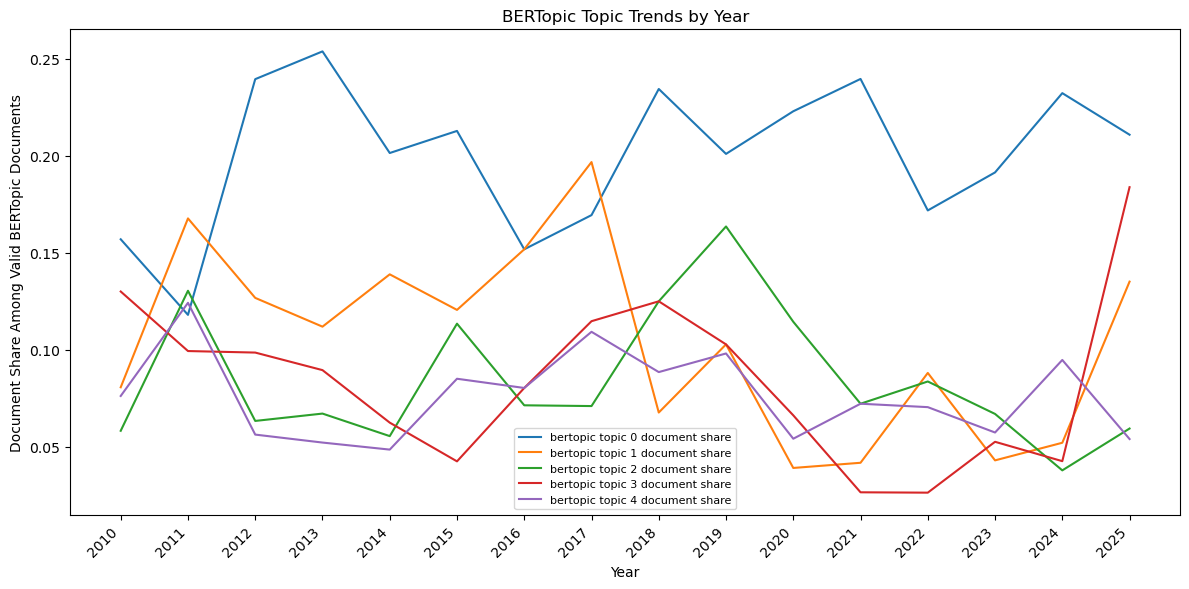

In [147]:
# Plot the top BERTopic topic trends by year.
plot_lines(
    bertopic_topic_trend_by_year,
    'year',
    bertopic_topic_trend_cols,
    'BERTopic Topic Trends by Year',
    'Document Share Among Valid BERTopic Documents',
    'bertopic_topic_trends_by_year.png',
    top_n=5
)